# Kaggriculture: Structured Economic Policy

Terminal bank is the common unit for every decision. Productive
assets matter only through the cash-conversion chain

$$
B_0
\longrightarrow K_t
\longrightarrow Y_t
\longrightarrow Z_t
\longrightarrow B_T,
$$

where $K_t$ is committed capital, $Y_t$ is physical output, and
$Z_t$ is liquidatable stock across the shed and carried inventories.
With 24 turns per day,

$$
T=720,
\qquad d_t=\left\lfloor\frac{t}{24}\right\rfloor,
\qquad h_t=t-24d_t.
$$

For seat $p\in\{0,1\}$, the terminal objective is

$$
\max_\pi\;\mathbb E_\pi
\!\left[B_T^{(p)}-B_T^{(1-p)}\right].
$$

Three invariants govern the allocation:

1. irreversible losses precede optional growth;
2. field commitments precede market commitments;
3. every commitment must remain terminally feasible: maturity,
   harvest, return, and sale all fit before $T$.


In [1]:
import subprocess, sys

# The environment the notebook renders must match the one the season is
# specified against; otherwise the animations below faithfully depict a
# run whose action space is not the one the policy was written for.
ENGINE = "1.32.4"
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                f"kaggle-environments=={ENGINE}"], check=True)
import kaggle_environments
assert kaggle_environments.__version__ == ENGINE, kaggle_environments.__version__


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 828.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 69.6 MB/s eta 0:00:00


In [2]:
from pathlib import Path
from IPython.core.magic import register_cell_magic

WORK_DIR = (
    Path("/kaggle/working")
    if Path("/kaggle/working").is_dir()
    else Path.cwd() / "policy_bundle_output"
)
WORK_DIR.mkdir(parents=True, exist_ok=True)
MAIN_PATH = WORK_DIR / "main.py"

@register_cell_magic
def agentfile(line, cell):
    mode = "a" if line.strip() == "append" else "w"
    with MAIN_PATH.open(mode, encoding="utf-8") as handle:
        handle.write(cell)

## 1. Causal ledger

One turn contains two ordered controllable ledgers. Let $a_t^F$
denote field actions and $a_t^M$ market orders. Their ordered
subtransition is

$$
s_t^{\mathrm{post}}
=\mathcal M\!\left(
  \mathcal F(s_t,a_t^F),a_t^M
\right).
$$

Town demand and the scheduled observation refresh then map
$s_t^{\mathrm{post}}$ to $s_{t+1}$. These exogenous updates cannot
reverse the field-before-market precedence.

Dropped stock can become sale-eligible in the same turn because
$\mathcal F$ precedes $\mathcal M$. The reverse implication is
invalid: same-turn purchases cannot fund planting, feeding, or
watering already resolved by $\mathcal F$.

Field planning cannot use any same-turn market proceeds:

$$
B_t^F=B_t.
$$

Market planning processes the ordered sale list before later capital
orders. It discounts projected proceeds and upper-bounds purchase
cost:

$$
B_t^M
=B_t
 +0.85\sum_{s\in\mathcal S_t}\widehat R_t(s)
 -\sum_{b\in\mathcal B_t}\overline c_t(b).
$$

Thus a market sale may fund a later market order, but never a field
action already resolved by $\mathcal F$.

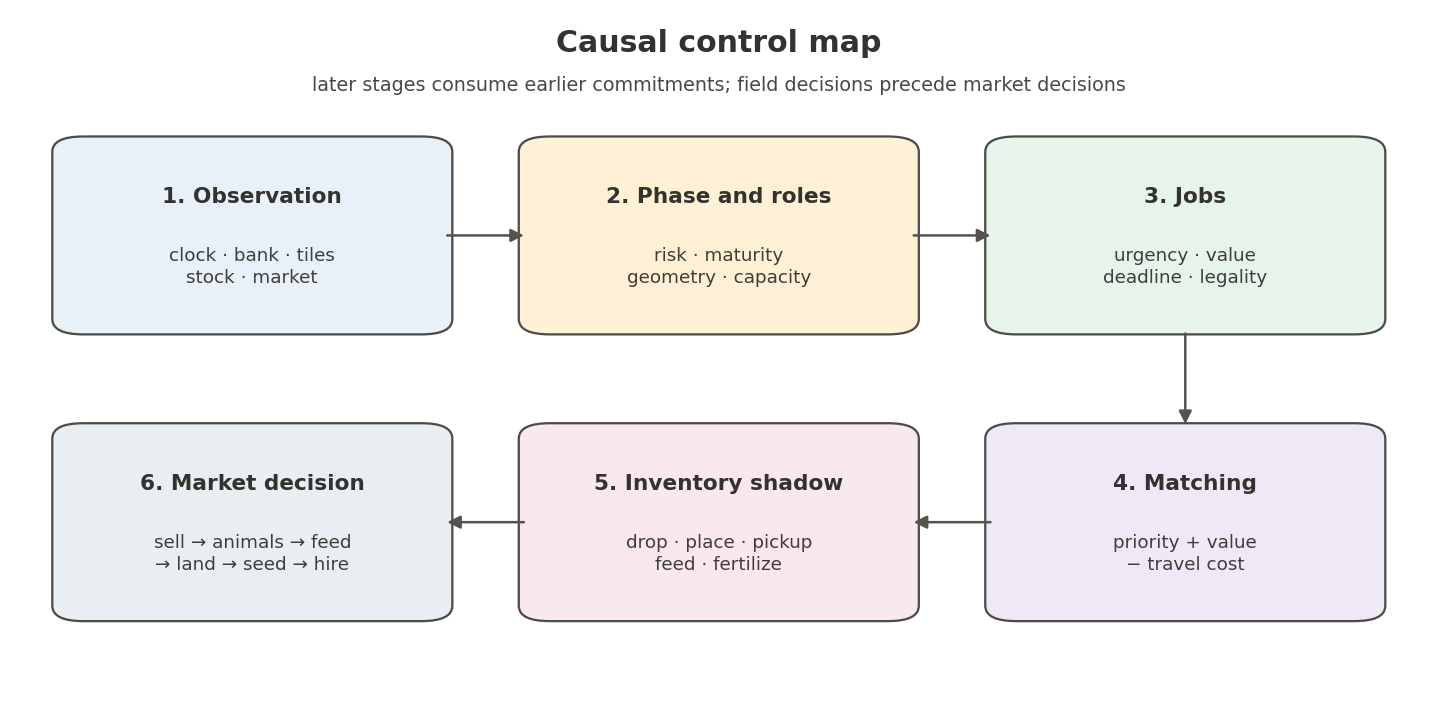

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from IPython.display import display

flow_nodes = (
    ("Observation", "clock · bank · tiles\nstock · market", "#E8F1F8"),
    ("Phase and roles", "risk · maturity\ngeometry · capacity", "#FFF1D5"),
    ("Jobs", "urgency · value\ndeadline · legality", "#E7F4EA"),
    ("Matching", "priority + value\n− travel cost", "#EEE8F7"),
    ("Inventory shadow", "drop · place · pickup\nfeed · fertilize", "#F9E8EF"),
    (
        "Market decision",
        "sell → animals → feed\n→ land → seed → hire",
        "#E9EEF2",
    ),
)
flow_positions = (
    (0.17, 0.68),
    (0.50, 0.68),
    (0.83, 0.68),
    (0.83, 0.27),
    (0.50, 0.27),
    (0.17, 0.27),
)

figure, axis = plt.subplots(figsize=(12.4, 6.2), dpi=120)
figure.patch.set_facecolor("white")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1)
axis.axis("off")
node_width, node_height = 0.255, 0.255

for index, ((title, detail, color), (x, y)) in enumerate(
    zip(flow_nodes, flow_positions), start=1
):
    axis.add_patch(
        FancyBboxPatch(
            (x - node_width / 2, y - node_height / 2),
            node_width,
            node_height,
            boxstyle="round,pad=0.014,rounding_size=0.022",
            facecolor=color,
            edgecolor="#4C4B47",
            linewidth=1.35,
        )
    )
    axis.text(
        x,
        y + 0.055,
        f"{index}. {title}",
        ha="center",
        va="center",
        fontsize=13,
        weight="bold",
        color="#33322F",
    )
    axis.text(
        x,
        y - 0.045,
        detail,
        ha="center",
        va="center",
        fontsize=11,
        linespacing=1.28,
        color="#3F3D38",
    )

for source, target in zip(flow_positions[:-1], flow_positions[1:]):
    source_x, source_y = source
    target_x, target_y = target
    if source_y == target_y:
        direction = 1 if target_x > source_x else -1
        start = (
            source_x + direction * (node_width / 2 + 0.008),
            source_y,
        )
        end = (
            target_x - direction * (node_width / 2 + 0.008),
            target_y,
        )
    else:
        direction = 1 if target_y > source_y else -1
        start = (
            source_x,
            source_y + direction * (node_height / 2 + 0.008),
        )
        end = (
            target_x,
            target_y - direction * (node_height / 2 + 0.008),
        )
    axis.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=1.5,
            color="#56534D",
        )
    )

axis.text(
    0.5,
    0.955,
    "Causal control map",
    ha="center",
    va="center",
    fontsize=18,
    weight="bold",
    color="#33322F",
)
axis.text(
    0.5,
    0.895,
    "later stages consume earlier commitments; field decisions precede market decisions",
    ha="center",
    va="center",
    fontsize=11.5,
    color="#4A4844",
)
figure.subplots_adjust(left=0.025, right=0.975, bottom=0.04, top=0.98)
display(
    figure,
    metadata={
        "image/png": {
            "alt": (
                "A two-row causal flow from observation through phase, "
                "jobs, matching, inventory shadow, and market decision."
            )
        }
    },
)
plt.close(figure)

## 2. Production value

A crop occupying one tile for $g_c$ days has discounted value

$$
V_c(t)=
\Pr(\text{service completed})\,
y_c\,\widehat p_c(t+g_c)
-s_c-\lambda_W w_c-\lambda_L g_c.
$$

Here $s_c$ is seed cost, $w_c$ is required service, and $\lambda_W$
and $\lambda_L$ are the shadow prices of labor and land. Planting is
admissible only when maturity and liquidation remain feasible:

$$
t+24g_c+\tau_c^{\mathrm{harvest}}
+\tau_c^{\mathrm{return}}<T.
$$

Livestock uses the same opportunity-cost principle. For species
$a$ producing item $r(a)$,

$$
V_a(t)=
\sum_{\substack{u\in\mathcal P_a\\t\le u<T}}
  \gamma^{u-t}
  \Pr(\text{fed at }u)\,
  y_{a,u}\widehat p_{r(a)}(u)
-c_a-\lambda_P-\lambda_W w_a.
$$

Here $\mathcal P_a$ is the set of scheduled production turns;
non-production turns contribute no revenue.

Feed, second-miss water, terminal harvest, and terminal unloading
receive lexicographic protection. Growth uses only the residual
service capacity.

## 3. Roles, jobs, and matching

Land geometry first creates spatial roles: crop service, livestock
service, inventory transport, and flexible support. Mission creation
converts urgency, loss risk, maturity, and terminal feasibility into
a discrete priority $p_j$ and an economic value $v_j$.

$$
S_{ij}=b_{p_j}+v_j-8d_1(x_i,x_j),
$$

where the priority bonuses are strictly ordered:

$$
(b_{-1},b_0,b_1,b_2,b_3,b_4,b_5)
=(120000,100000,1500,750,250,0,-100).
$$

A pair is admitted only if the unit can reach the mission before its
deadline, the required carried item exists, the destination remains
legal, and terminal return is feasible. Candidate pairs are sorted
by descending $S_{ij}$, then distance and stable indices. Each unit
and each mission is consumed at most once. Inventory shadows are
updated immediately after assignment, so later pairs cannot spend an
item already committed by an earlier pair.

## 4. Workload-responsive labor

Let $H_t$ be hired hands, $U_t=1+H_t$ the total field units,
$J_t$ the due jobs, and $R_t$ the assets exposed to a second missed
service. The desired number of hired hands is

$$
H_t^*=\min\!\left(
  \overline H(d_t),
  \max\!\left[
    H_t^{\mathrm{floor}},
    \left\lceil\frac{J_t+2R_t}{7}\right\rceil
  \right]
\right),
$$

with the maturity-dependent ceiling

$$
\overline H(d_t)=
\begin{cases}
12,&d_t<20,\\
13,&d_t\ge20.
\end{cases}
$$

The zero-based condition $d_t\ge20$ begins on displayed Day 21.
The workload floor is ten while productive roles remain active
through $d_t=27$, and four otherwise. On the terminal day, hours
zero and one use the separate recovery target

$$
H_t^{\mathrm{terminal}}
=\min\!\left(8,J_t^{\mathrm{terminal}}\right).
$$

Labor cost is convex:

$$
F_0=F_1=1,
\qquad F_n=F_{n-1}+F_{n-2},
\qquad C(H)=\sum_{n=0}^{H-1}F_n.
$$

In particular,

$$
C(12)=376,
\qquad C(13)=609,
\qquad C(13)-C(12)=F_{12}=233.
$$

Before displayed Day 21, this marginal wage competes with land,
livestock, feed, and crop capital. After the recurring production
system has matured, the thirteenth hand is available only when the
job ledger and protected residual cash both justify its throughput.

Ordinary hiring requires both workload and residual market liquidity:

$$
h_t\le2,
\quad H_t<H_t^*,
\quad B_{t,k}^{M,\mathrm{res}}\ge\max(20,3F_{H_t}),
\quad |\mathcal M_t|<10.
$$

Terminal recovery is admitted separately when

$$
h_t\le1,
\quad H_t<H_t^{\mathrm{terminal}},
\quad B_{t,k}^{M,\mathrm{res}}\ge F_{H_t}+20,
\quad |\mathcal M_t|<10.
$$

## 5. Shared-market dynamics

Let $I_{r,t}$ be public inventory for product $r$, $D_{r,t}$ total
purchases, $S_{r,t}^{+}$ inventory-accreting sales, and $C_{r,t}$
town consumption. A sold unit contributes to $S_{r,t}^{+}$ only
when its clearing price exceeds the one-dollar floor.

$$
I_{r,t+1}=I_{r,t}+S_{r,t}^{+}-D_{r,t}-C_{r,t}.
$$

A unit sold at the floor still earns one dollar and leaves private
stock, but it does not increase public market inventory.

The marginal price is a rounded monotone inventory curve around
equilibrium $I_{0,r}$:

$$
p_r(I)=\max\!\left(1,\operatorname{round}\widetilde p_r(I)\right),
\qquad
\widetilde p_r(I)=
\begin{cases}
b_r+\alpha_r^- f_r^-(I_{0,r}-I),&I<I_{0,r},\\
b_r-\alpha_r^+ f_r^+(I-I_{0,r}),&I\ge I_{0,r}.
\end{cases}
$$

Purchases follow the projected unitwise marginal curve. Sales
contribute only $85\%$ of their projected proceeds to the planning
ledger. The haircut reduces financing risk; residual mismatch is
handled by unitwise partial fill.

## 6. Price impact and the symmetry of order timing

Sales are filled unit by unit along the inventory curve, so a block of
$x$ units sold from inventory $I$ realises

$$
R(x\mid I)=\sum_{i=0}^{x-1}p_r(I+i),
\qquad
\delta_r(J)=p_r(J)-p_r(J+1)\ \ge 0 .
$$

Consider a counterparty whose block of $q$ units is committed in advance,
so its size does not react to price, and suppose we place $x$ units
immediately before it. Relative to placing our units after the block, the
two banks move by

$$
\Delta_{\text{ours}}=R(x\mid I)-R(x\mid I+q),
\qquad
\Delta_{\text{theirs}}=R(q\mid I)-R(q\mid I+x).
$$

Telescoping each difference over the intervening units gives the same
rectangle of marginal price steps,

$$
\Delta_{\text{ours}}
=\sum_{i=0}^{x-1}\sum_{j=0}^{q-1}\delta_r(I+i+j)
=\Delta_{\text{theirs}} .
$$

The advantage we take is therefore exactly the concession we impose, and
the objective of §1 moves by

$$
\Delta\!\left[B_T^{(p)}-B_T^{(1-p)}\right]
=2\sum_{i=0}^{x-1}\sum_{j=0}^{q-1}\delta_r(I+i+j).
$$

The factor two is the whole content of order timing against a
non-reacting block: the swing is twice the price impact, and it is
computable in closed form from the curve alone, with no simulation.

## 7. Where the curve bites

The margin swing above is governed by $\delta_r$, not by the block size
alone. Because the curve is assembled from a different shape on each side
of the equilibrium inventory,

$$
\delta_r(J)\approx
\begin{cases}
\alpha_r^-\,\dfrac{\mathrm d}{\mathrm dJ}f_r^-(I_{0,r}-J), & J<I_{0,r},\\[2ex]
\alpha_r^+\,\dfrac{\mathrm d}{\mathrm dJ}f_r^+(J-I_{0,r}), & J\ge I_{0,r},
\end{cases}
$$

the same product can be nearly inelastic on one side and violently
elastic on the other. A logarithmic side flattens as it extends,
$\mathrm df^{-}/\mathrm dJ\to0$; a quadratic side steepens without bound,
$\mathrm df^{+}/\mathrm dJ\propto (J-I_{0,r})$.

The consequence is operational. Town consumption drains inventory
continuously, so a season spends most of its length *below* equilibrium.
A block that appears decisive when priced at $I_{0,r}$ can be worth two
orders of magnitude less at the inventory the season actually reaches.
Plans are therefore evaluated on the realised inventory path
$\{I_{r,t}\}$, never at the reference point.

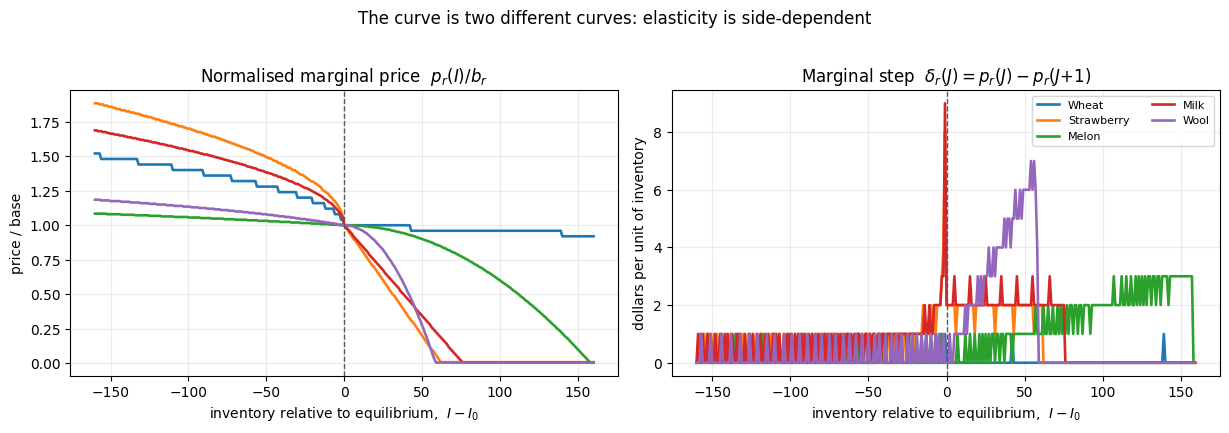

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Marginal price step delta_r(J) = p_r(J) - p_r(J+1) around equilibrium.
I0 = 10_000
PARAMS = {
    "WHEAT":      {"base":  25, "T": 400, "bf": "sqrt",   "bt": 0.80, "af": "log",    "at": 0.20},
    "STRAWBERRY": {"base": 120, "T": 100, "bf": "sqrt",   "bt": 0.70, "af": "linear", "at": 1.60},
    "MELON":      {"base": 250, "T": 300, "bf": "log",    "bt": 0.20, "af": "sq",     "at": 3.60},
    "MILK":       {"base": 160, "T": 122, "bf": "sqrt",   "bt": 0.60, "af": "linear", "at": 1.60},
    "WOOL":       {"base": 200, "T": 105, "bf": "log",    "bt": 0.20, "af": "sq",     "at": 3.20},
}
SHAPE = {"linear": lambda u: u, "sqrt": lambda u: np.sqrt(u),
         "log": lambda u: np.log1p(u), "sq": lambda u: u ** 2}

def price(name, inv):
    p = PARAMS[name]
    u = np.abs(inv - I0) / p["T"]
    below = p["base"] + p["bt"] * p["base"] * SHAPE[p["bf"]](u)
    above = p["base"] - p["at"] * p["base"] * SHAPE[p["af"]](u)
    return np.maximum(1.0, np.round(np.where(inv < I0, below, above)))

grid = np.arange(I0 - 160, I0 + 161)
step = np.arange(I0 - 160, I0 + 160)
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))
for name in PARAMS:
    axes[0].plot(grid - I0, price(name, grid) / PARAMS[name]["base"], lw=1.9, label=name.title())
    axes[1].plot(step - I0, price(name, step) - price(name, step + 1), lw=1.9, label=name.title())
axes[0].set_title("Normalised marginal price  $p_r(I)/b_r$")
axes[0].set_ylabel("price / base")
axes[1].set_title(r"Marginal step  $\delta_r(J)=p_r(J)-p_r(J{+}1)$")
axes[1].set_ylabel("dollars per unit of inventory")
for ax in axes:
    ax.axvline(0, color="0.35", lw=1.0, ls="--")
    ax.set_xlabel(r"inventory relative to equilibrium,  $I-I_0$")
    ax.grid(alpha=0.25)
axes[1].legend(fontsize=8, ncol=2)
fig.suptitle("The curve is two different curves: elasticity is side-dependent", y=1.02)
fig.tight_layout()
plt.show()

## 8. The objective is a difference, not a level

Let $\mathcal H\subset\{0,\dots,T-1\}$ be a window over which we withhold
$\Delta z$ units of product $r$ that would otherwise have been sold. The
inventory path over that window is uniformly lower, hence the price path
is uniformly higher:

$$
I_{r,t}^{\text{hold}}\le I_{r,t},
\qquad
p_r\!\left(I_{r,t}^{\text{hold}}\right)\ \ge\ p_r\!\left(I_{r,t}\right)
\quad\text{for all } t\in\mathcal H .
$$

Every seat trading in $\mathcal H$ is paid on that same elevated path. If
the counterparty moves $v^{(1-p)}$ units through the window against our
$v^{(p)}$, the first-order effect on the objective is

$$
\Delta\!\left[B_T^{(p)}-B_T^{(1-p)}\right]
\;\approx\;
\left(v^{(p)}-v^{(1-p)}\right)\cdot
\overline{\Delta p_r},
$$

so withholding is a transfer *to* the counterparty whenever it is the
larger supplier in that window, however much it raises our own bank.

Two consequences shape the policy. First, maximising $B_T^{(p)}$ and
maximising the difference are distinct problems, and a change that
improves the first can worsen the second. Second, the marginal value of
any timing decision depends on the other seat's volume in the same
window, which is observable only through the public inventory path — so
sizing is computed against $\{I_{r,t}\}$ rather than against our own
holdings alone.

## 9. Execution invariants

The final decision satisfies

$$
|a_t^{\mathrm{field}}|\le N_t^{\mathrm{units}},
\qquad
|a_t^{\mathrm{market}}|\le10.
$$

State resets are keyed by seat, board size, clock, and decreasing
canonical turn. Exceptions, malformed observations, and unsupported
configurations return the ordinary action already computed for that
turn.


In [5]:
%%agentfile
"""Deterministic scenario-aware economic policy for Kaggriculture."""

from collections import deque
import math


# Domain constants

CROPS = {
    "WHEAT": {
        "seed": 10,
        "first": 2,
        "max_day": 4,
        "max_yield": 6,
        "ongoing": False,
        "ripe": 4,
        "last_plant": 24,
    },
    "CARROT": {
        "seed": 20,
        "first": 2,
        "max_day": 3,
        "max_yield": 4,
        "ongoing": False,
        "ripe": 3,
        "last_plant": 25,
    },
    "TOMATO": {
        "seed": 50,
        "first": 8,
        "max_day": 8,
        "max_yield": 4,
        "ongoing": True,
        "interval": 1,
        "ripe": 8,
        "last_plant": 19,
    },
    "STRAWBERRY": {
        "seed": 100,
        "first": 10,
        "max_day": 10,
        "max_yield": 4,
        "ongoing": True,
        "interval": 2,
        "ripe": 10,
        "last_plant": 18,
    },
    "MELON": {
        "seed": 80,
        "first": 10,
        "max_day": 12,
        "max_yield": 6,
        "ongoing": False,
        "ripe": 10,
        "last_plant": 18,
    },
}

ANIMALS = {
    "GOOSE": {
        "cost": 300,
        "structure": "COOP",
        "product": "EGG",
        "first": 4,
        "interval": 1,
        "max_held": 4,
    },
    "COW": {
        "cost": 400,
        "structure": "PASTURE",
        "product": "MILK",
        "first": 8,
        "interval": 2,
        "max_held": 6,
    },
    "SHEEP": {
        "cost": 500,
        "structure": "PASTURE",
        "product": "WOOL",
        "first": 6,
        "interval": 3,
        "max_held": 6,
    },
}

PRODUCTS = (
    "WHEAT",
    "CARROT",
    "TOMATO",
    "STRAWBERRY",
    "MELON",
    "EGG",
    "MILK",
    "WOOL",
    "FERTILIZER",
)

MARKET = {
    "WHEAT": (25, 400, "sqrt", 0.80, "log", 0.20),
    "CARROT": (35, 450, "log", 0.20, "sqrt", 0.70),
    "TOMATO": (60, 200, "linear", 0.40, "sqrt", 0.60),
    "STRAWBERRY": (120, 100, "sqrt", 0.70, "linear", 1.60),
    "MELON": (250, 300, "log", 0.20, "sq", 3.60),
    "EGG": (50, 332, "linear", 0.40, "log", 0.20),
    "MILK": (160, 122, "sqrt", 0.60, "linear", 1.60),
    "WOOL": (200, 105, "log", 0.20, "sq", 3.20),
    "FERTILIZER": (100, 200, "linear", 0.40, "linear", 0.40),
}

SHOPS = {
    "BAKERY": ("EGG", "WHEAT"),
    "PIZZA_SHOP": ("MILK", "TOMATO", "WHEAT"),
    "BRUNCH_SPOT": ("EGG", "WHEAT", "STRAWBERRY"),
    "YARN_STORE": ("WOOL",),
    "ICE_CREAM_SHOP": ("STRAWBERRY", "MILK", "WHEAT"),
    "PET_CAFE": ("CARROT",),
    "SMOOTHIE_SHOP": ("STRAWBERRY", "MILK"),
    "FARMERS_MARKET": ("WHEAT", "CARROT", "TOMATO", "STRAWBERRY"),
}

RESERVE_FRACTION = {
    "WHEAT": 0.68,
    "CARROT": 0.55,
    "TOMATO": 0.50,
    "STRAWBERRY": 0.48,
    "MELON": 0.58,
    "EGG": 0.65,
    "MILK": 0.42,
    "WOOL": 0.40,
    "FERTILIZER": 0.18,
}

MOVES = (
    ("NORTH", 0, -1),
    ("WEST", -1, 0),
    ("SOUTH", 0, 1),
    ("EAST", 1, 0),
)

LAND_PRICES = (1000, 2000, 4000)
MARKET_I0 = 10000
TOTAL_DAYS = 30
MAX_MARKET_ORDERS = 10
MAX_HANDS = 12
CORE_HERD_SEQUENCE = ("COW", "COW", "COW", "SHEEP")
CORE_HERD = len(CORE_HERD_SEQUENCE)
MID_HERD = 11
TARGET_HERD = 15
HERD_EXPANSION_DAY = 7
HERD_FINAL_DAY = 11
ANIMAL_PURCHASE_LAST_DAY = 18
ANIMAL_SLOTS = {"NW": 4, "NE": 7, "SW": 4, "SE": 0}
CROP_MIX = {
    "NW": {"MELON": 10, "WHEAT": 4, "CARROT": 2},
    "NE": {"WHEAT": 4, "CARROT": 1},
    "SW": {"WHEAT": 4, "CARROT": 1},
    "SE": {"WHEAT": 5, "CARROT": 2},
}
MELON_TILES_MIN = 8
MELON_TILES_BASE = 10
MELON_TILES_MAX = 12
MAX_EXTRA_LAND = 2
CASH_RESERVE = 250
LIQUIDATION_TURNS = 22
SHED_CAPACITY = 100
TRAVEL_COST = 8.0
FEED_STOCK_DAYS = 3
SCHEDULE_WHEAT_CAP = 100
LAND_OPEN_DAYS = (5, 9)
PRIORITY_BONUS = {
    -1: 120_000.0,
    0: 100_000.0,
    1: 1_500.0,
    2: 750.0,
    3: 250.0,
    4: 0.0,
    5: -100.0,
}

_SIGNATURE_LAST_STEP = -1
_SIGNATURE_ACTIVE = False
_SCHEDULE_WHEAT_REQUESTED = 0


# Configuration, pricing, and routing helpers

def _cfg(config, key, default):
    if config is None:
        return default
    if isinstance(config, dict):
        return config.get(key, default)
    return getattr(config, key, default)


def _shape(name, value):
    value = max(0.0, float(value))
    if name == "linear":
        return value
    if name == "sq":
        return value * value
    if name == "sqrt":
        return math.sqrt(value)
    if name == "log":
        return math.log1p(value)
    if name == "log10":
        return math.log10(1.0 + value)
    return value


def _market_parameters(obs, item):
    base, throughput, below_fn, below_move, above_fn, above_move = MARKET[item]
    custom = (((obs or {}).get("market", {}) or {}).get("params", {}) or {}).get(
        item, {}
    )
    return (
        float(custom.get("base", base)),
        float(custom.get("T", throughput)),
        str(custom.get("below_func", below_fn)),
        float(custom.get("below_target", below_move)),
        str(custom.get("above_func", above_fn)),
        float(custom.get("above_target", above_move)),
        float(custom.get("I0", MARKET_I0)),
    )


def _price_at(item, inventory, obs=None):
    (
        base,
        throughput,
        below_fn,
        below_move,
        above_fn,
        above_move,
        equilibrium,
    ) = _market_parameters(obs, item)
    if inventory < equilibrium:
        amplitude = below_move * base / max(1e-9, _shape(below_fn, throughput))
        value = base + amplitude * _shape(below_fn, equilibrium - inventory)
    else:
        amplitude = above_move * base / max(1e-9, _shape(above_fn, throughput))
        value = base - amplitude * _shape(above_fn, inventory - equilibrium)
    return max(1, int(round(value)))


def _town_demand_per_day(obs, item):
    day = int((obs or {}).get("day", 0) or 0)
    center = 0 if item == "FERTILIZER" else 2 * (
        4 if day >= 20 else 2 if day >= 10 else 1
    )
    shop = 0
    for name in (((obs or {}).get("town", {}) or {}).get(
        "unlocked_shops", []
    ) or []):
        products = SHOPS.get(name, ())
        if item in products:
            shop += 12 if len(products) == 1 else 6
    return center + shop


def _opponent_visible_supply(obs, item, horizon=1):
    player = int((obs or {}).get("player", 0) or 0)
    day = int((obs or {}).get("day", 0) or 0)
    animal_for = {"EGG": "GOOSE", "MILK": "COW", "WOOL": "SHEEP"}
    total = 0
    for index, farm in enumerate((obs or {}).get("farms", []) or []):
        if index == player:
            continue
        for row in farm.get("tiles", []) or []:
            for tile in row:
                if not isinstance(tile, dict):
                    continue
                if (
                    item in CROPS
                    and tile.get("kind") == "PLANT"
                    and tile.get("crop") == item
                ):
                    rule = CROPS[item]
                    planted = tile.get("planted_day")
                    planted_day = day if planted is None else int(planted)
                    age = day - planted_day
                    held = int(tile.get("yield_units", 0) or 0)
                    if held > 0 and age >= rule["first"]:
                        total += held
                    elif age + horizon >= rule["ripe"]:
                        total += max(1, min(rule["max_yield"], held + horizon))
                elif item in animal_for and tile.get("animal") == animal_for[item]:
                    total += int(tile.get("yield_units", 0) or 0)
                    if horizon > 0:
                        total += min(2 * horizon, ANIMALS.get(
                            tile.get("animal"), {"max_held": 4}
                        )["max_held"])
    return total


def _distance(a, b):
    return abs(int(a[0]) - int(b[0])) + abs(int(a[1]) - int(b[1]))


def _shed_tiles(board_size, tiles=None):
    half = board_size // 2
    candidates = (
        (half - 1, half - 1),
        (half, half - 1),
        (half - 1, half),
        (half, half),
    )
    if tiles is None:
        return candidates
    accessible = tuple(
        position
        for position in candidates
        if tiles[position[1]][position[0]] != "LOCKED"
    )
    return accessible or candidates[:1]


def _nearest_shed(position, board_size, tiles=None):
    return min(
        _shed_tiles(board_size, tiles),
        key=lambda target: (_distance(position, target), target[1], target[0]),
    )


def _bfs_first_step(tiles, source, target):
    source = (int(source[0]), int(source[1]))
    target = (int(target[0]), int(target[1]))
    if source == target:
        return ["PASS"]
    board_size = len(tiles)
    queue = deque([source])
    parent = {source: None}
    parent_move = {}
    while queue:
        current = queue.popleft()
        if current == target:
            break
        for name, dx, dy in MOVES:
            nxt = (current[0] + dx, current[1] + dy)
            if not (0 <= nxt[0] < board_size and 0 <= nxt[1] < board_size):
                continue
            if nxt in parent or tiles[nxt[1]][nxt[0]] == "LOCKED":
                continue
            parent[nxt] = current
            parent_move[nxt] = name
            queue.append(nxt)
    if target not in parent:
        return ["PASS"]
    current = target
    while parent[current] != source:
        current = parent[current]
        if current is None:
            return ["PASS"]
    return [parent_move[current]]


def _melon_target(obs):
    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    price = int(prices.get("MELON", MARKET["MELON"][0]) or MARKET["MELON"][0])
    opponent_tiles = 0
    player = int(obs.get("player", 0) or 0)
    for index, other in enumerate(obs.get("farms", []) or []):
        if index == player:
            continue
        for row in other.get("tiles", []) or []:
            opponent_tiles += sum(
                isinstance(tile, dict)
                and tile.get("kind") == "PLANT"
                and tile.get("crop") == "MELON"
                for tile in row
            )
    if price >= 300 and opponent_tiles <= 5:
        return MELON_TILES_MAX
    if price <= 170 or opponent_tiles >= 12:
        return MELON_TILES_MIN
    if opponent_tiles >= 9:
        return MELON_TILES_BASE - 1
    return MELON_TILES_BASE


def _private_item_total(private, item):
    total = int((private.get("shed", {}) or {}).get(item, 0) or 0)
    for inventory in private.get("inventories", []) or []:
        total += int((inventory or {}).get(item, 0) or 0)
    return total


def _farm_animal_counts(farm):
    counts = {animal: 0 for animal in ANIMALS}
    for row in farm.get("tiles", []) or []:
        for tile in row:
            if isinstance(tile, dict) and tile.get("animal") in counts:
                counts[tile["animal"]] += 1
    return counts


def _opponent_animal_counts(obs):
    player = int(obs.get("player", 0) or 0)
    counts = {animal: 0 for animal in ANIMALS}
    for index, farm in enumerate(obs.get("farms", []) or []):
        if index == player:
            continue
        visible = _farm_animal_counts(farm)
        for animal, count in visible.items():
            counts[animal] += count
    return counts


def _public_type_counts(farm):
    counts = {}
    for row in farm.get("tiles", []) or []:
        for tile in row:
            if not isinstance(tile, dict):
                continue
            if tile.get("kind") == "PLANT":
                name = str(tile.get("crop", "UNKNOWN"))
            elif tile.get("animal"):
                name = str(tile["animal"])
            else:
                name = str(tile.get("kind", "STRUCTURE"))
            counts[name] = counts.get(name, 0) + 1
    return counts


def _schedule_signature(obs):
    global _SIGNATURE_ACTIVE, _SIGNATURE_LAST_STEP
    raw_step = obs.get("step")
    step = int(
        raw_step
        if raw_step is not None
        else 24 * int(obs.get("day", 0) or 0) + int(obs.get("hour", 0) or 0)
    )
    if step == 0 or step <= _SIGNATURE_LAST_STEP:
        _SIGNATURE_ACTIVE = False
    _SIGNATURE_LAST_STEP = step

    farms = obs.get("farms", []) or []
    player = int(obs.get("player", 0) or 0)
    if len(farms) != 2 or not (0 <= player < 2):
        return False
    opponent = farms[1 - player]
    counts = _public_type_counts(opponent)

    if step == 24:
        hard_negative = any(
            counts.get(item, 0) for item in ("GOOSE", "CARROT", "TOMATO")
        )
        _SIGNATURE_ACTIVE = (
            not hard_negative
            and len(opponent.get("unlocked_quadrants", []) or []) == 1
            and counts.get("COW", 0) == 3
            and counts.get("SHEEP", 0) == 1
            and counts.get("MELON", 0) == 6
            and counts.get("STRAWBERRY", 0) == 0
        )
    if step == 192 and _SIGNATURE_ACTIVE:
        _SIGNATURE_ACTIVE = (
            len(opponent.get("unlocked_quadrants", []) or []) == 1
            and 3 <= counts.get("COW", 0) <= 5
            and counts.get("SHEEP", 0) == 1
            and 9 <= counts.get("MELON", 0) <= 10
            and 6 <= counts.get("STRAWBERRY", 0) <= 7
        )
    if step == 264 and _SIGNATURE_ACTIVE:
        hard_negative = any(
            counts.get(item, 0) for item in ("GOOSE", "CARROT", "TOMATO")
        )
        _SIGNATURE_ACTIVE = (
            not hard_negative
            and len(opponent.get("unlocked_quadrants", []) or []) == 2
            and 3 <= counts.get("COW", 0) <= 5
            and counts.get("SHEEP", 0) == 5
            and counts.get("MELON", 0) == 6
            and 15 <= counts.get("STRAWBERRY", 0) <= 16
            and 4 <= counts.get("PASTURE", 0) <= 5
        )
    return _SIGNATURE_ACTIVE


def _livestock_score(obs, animal, own_count, opponent_count):
    rule = ANIMALS[animal]
    product = rule["product"]
    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    price = float(prices.get(product, MARKET[product][0]) or MARKET[product][0])
    normalized_price = price / float(MARKET[product][0])
    demand_support = 1.0 + 0.012 * _town_demand_per_day(obs, product)
    crowding = 1.0 + 0.18 * opponent_count + 0.08 * own_count
    return normalized_price * demand_support / crowding


def _quadrant_of(position, board_size):
    x, y = position
    half = board_size // 2
    return ("N" if y < half else "S") + ("W" if x < half else "E")


def _reserved_animal_slots(farm):
    tiles = farm.get("tiles", []) or []
    board_size = len(tiles)
    unlocked = set(farm.get("unlocked_quadrants", []) or ["NW"])
    sheds = _shed_tiles(board_size, tiles)
    slots = []
    by_quadrant = {}
    for quadrant in ("NW", "NE", "SW", "SE"):
        if quadrant not in unlocked:
            continue
        cells = []
        for y, row in enumerate(tiles):
            for x, tile in enumerate(row):
                if tile == "LOCKED" or _quadrant_of((x, y), board_size) != quadrant:
                    continue
                distance = min(_distance((x, y), shed) for shed in sheds)
                cells.append((distance, y, x))
        cells.sort()
        count = min(ANIMAL_SLOTS[quadrant], len(cells))
        selected = [(x, y) for _, y, x in cells[:count]]
        by_quadrant[quadrant] = {
            "reserved": selected,
            "crops": [(x, y) for _, y, x in cells[count:]],
        }
        slots.extend(selected)
    return slots, by_quadrant


def _herd_targets(obs, farm, private, capacity):
    day = int(obs.get("day", 0) or 0)
    left = TOTAL_DAYS - day
    placed = _farm_animal_counts(farm)
    owned = {
        animal: placed[animal] + _private_item_total(private, animal)
        for animal in ("COW", "SHEEP")
    }
    if day < HERD_EXPANSION_DAY:
        stage_target = CORE_HERD
    elif day < HERD_FINAL_DAY:
        stage_target = MID_HERD
    else:
        stage_target = TARGET_HERD
    if day > ANIMAL_PURCHASE_LAST_DAY or left < 8:
        stage_target = sum(owned.values())
    target_total = min(capacity, max(sum(owned.values()), stage_target))

    targets = {
        animal: max(
            CORE_HERD_SEQUENCE.count(animal)
            if target_total >= CORE_HERD
            else 0,
            owned[animal],
        )
        for animal in ("COW", "SHEEP")
    }
    opponents = _opponent_animal_counts(obs)
    while sum(targets.values()) < target_total:
        animal = max(
            ("COW", "SHEEP"),
            key=lambda name: (
                _livestock_score(
                    obs,
                    name,
                    targets[name],
                    opponents[name],
                ),
                -targets[name],
                name == "COW",
            ),
        )
        targets[animal] += 1
    return targets


def _role_plan(obs, farm):
    private = obs.get("private", {}) or {}
    tiles = farm.get("tiles", []) or []
    animal_slots, zones = _reserved_animal_slots(farm)
    targets = _herd_targets(obs, farm, private, len(animal_slots))
    desired_animals = min(len(animal_slots), sum(targets.values()))
    active_slots = list(animal_slots[:desired_animals])
    for position in animal_slots:
        x, y = position
        tile = tiles[y][x]
        if isinstance(tile, dict) and "animal" in tile and position not in active_slots:
            active_slots.append(position)

    assigned = {"COW": 0, "SHEEP": 0}
    roles = {}
    core_sequence = CORE_HERD_SEQUENCE
    for index, position in enumerate(active_slots):
        x, y = position
        tile = tiles[y][x]
        actual = tile.get("animal") if isinstance(tile, dict) else None
        if actual in assigned:
            animal = actual
        elif index < len(core_sequence) and assigned[core_sequence[index]] < targets[
            core_sequence[index]
        ]:
            animal = core_sequence[index]
        else:
            animal = max(
                ("COW", "SHEEP"),
                key=lambda name: (
                    targets[name] - assigned[name],
                    _private_item_total(private, name),
                    name == "COW",
                ),
            )
        roles[position] = ("ANIMAL", animal)
        assigned[animal] += 1

    melon_target = _melon_target(obs)
    for quadrant in ("NW", "NE", "SW", "SE"):
        zone = zones.get(quadrant)
        if not zone:
            continue
        cells = zone["crops"]
        fixed = dict(CROP_MIX[quadrant])
        if quadrant == "NW":
            fixed["MELON"] = min(melon_target, len(cells))
        strawberry_count = max(0, len(cells) - sum(fixed.values()))
        sequence = []
        if quadrant == "NW":
            sequence.extend(["MELON"] * fixed.get("MELON", 0))
        sequence.extend(["STRAWBERRY"] * strawberry_count)
        sequence.extend(["WHEAT"] * fixed.get("WHEAT", 0))
        sequence.extend(["CARROT"] * fixed.get("CARROT", 0))
        if quadrant != "NW":
            sequence.extend(["MELON"] * fixed.get("MELON", 0))
        for position, crop in zip(cells, sequence):
            roles[position] = ("CROP", crop)
    return roles


# Observation summaries and job generation

def _inventory_total(inventory, excluded=()):
    return sum(
        int(value)
        for item, value in (inventory or {}).items()
        if item not in excluded and isinstance(value, (int, float)) and value > 0
    )


def _survey(farm, private, roles=None, day=0):
    summary = {
        "animals": 0,
        "unfed": 0,
        "at_risk_animals": 0,
        "at_risk_crops": 0,
        "open_structures": 0,
        "structures_todo": 0,
        "plants": 0,
        "plantable": 0,
        "weeds": 0,
    }
    for row in farm.get("tiles", []) or []:
        for tile in row:
            if not isinstance(tile, dict):
                continue
            if "animal" in tile:
                summary["animals"] += 1
                if not tile.get("fed_today", False):
                    summary["unfed"] += 1
                if int(tile.get("consecutive_unfed", 0) or 0) >= 1:
                    summary["at_risk_animals"] += 1
            elif tile.get("kind") in {"COOP", "PASTURE"}:
                summary["open_structures"] += 1
            elif tile.get("kind") == "PLANT":
                summary["plants"] += 1
                if int(tile.get("consecutive_unwatered", 0) or 0) >= 1:
                    summary["at_risk_crops"] += 1
            elif tile.get("kind") == "WEED":
                summary["weeds"] += 1

    if roles:
        for (x, y), (kind, item) in roles.items():
            tile = farm["tiles"][y][x]
            if kind == "ANIMAL" and tile is None:
                summary["structures_todo"] += 1
            elif (
                kind == "CROP"
                and tile is None
                and day <= CROPS[item]["last_plant"]
            ):
                summary["plantable"] += 1

    summary["wheat_stock"] = int((private.get("shed", {}) or {}).get("WHEAT", 0))
    summary["animal_stock"] = {
        animal: int((private.get("shed", {}) or {}).get(animal, 0) or 0)
        for animal in ANIMALS
    }
    summary["shed_load"] = sum(
        max(0, int(value or 0))
        for value in (private.get("shed", {}) or {}).values()
    )
    summary["carried_load"] = 0
    for inventory in private.get("inventories", []) or []:
        summary["wheat_stock"] += int((inventory or {}).get("WHEAT", 0))
        for animal in ANIMALS:
            summary["animal_stock"][animal] += int(
                (inventory or {}).get(animal, 0) or 0
            )
        summary["carried_load"] += _inventory_total(inventory)
    return summary


def _policy_phase(obs, farm, private, summary):
    day = int(obs.get("day", 0) or 0)
    step = int(obs.get("step", day * 24 + int(obs.get("hour", 0) or 0)) or 0)
    actions_left = max(0, 719 - step)
    if actions_left <= LIQUIDATION_TURNS:
        return "LIQUIDATE"
    workers = 1 + len(farm.get("hands", []) or [])
    if (
        summary["at_risk_animals"] + summary["at_risk_crops"] > workers
        or summary["shed_load"] + summary["carried_load"] >= 95
    ):
        return "CRISIS"
    if day <= 4:
        return "BOOTSTRAP"
    if day <= 21:
        return "COMPOUND"
    return "REALIZE"


def _add_job(
    jobs,
    priority,
    value,
    target,
    action,
    need=None,
    reason="",
    latest_hour=23,
):
    jobs.append(
        {
            "priority": int(priority),
            "value": float(value),
            "target": tuple(target),
            "action": list(action),
            "need": need,
            "reason": str(reason),
            "latest_hour": int(latest_hour),
        }
    )


def _animal_produces_tonight(tile, rule, day):
    next_day = int(day) + 1
    placed_day = int(tile.get("placed_day", day) or 0)
    days_since_first = next_day - placed_day - int(rule["first"])
    return (
        days_since_first >= 0
        and days_since_first % int(rule["interval"]) == 0
    )


def _crop_jobs(obs, jobs, tile, target, day, liquidation):
    crop = tile.get("crop")
    rule = CROPS.get(crop)
    if rule is None:
        return
    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    price = float(prices.get(crop, MARKET[crop][0]) or MARKET[crop][0])
    age = day - int(tile.get("planted_day", day))
    amount = int(tile.get("yield_units", 0) or 0)
    watered = bool(tile.get("watered_today", False))
    drought = int(tile.get("consecutive_unwatered", 0) or 0)
    critical = drought >= 1

    if liquidation:
        if amount > 0 and age >= rule["first"]:
            _add_job(
                jobs,
                0,
                amount * price,
                target,
                ("HARVEST",),
                reason="terminal_harvest",
            )
        return

    if critical and not watered:
        protected = max(amount, rule["max_yield"] * 0.7) * price
        _add_job(
            jobs,
            0,
            protected,
            target,
            ("WATER",),
            reason="critical_water",
        )
        return

    if rule["ongoing"]:
        next_day = day + 1
        interval = max(1, int(rule.get("interval", 1)))
        days_since_first = (
            next_day - int(tile.get("planted_day", day)) - rule["first"]
        )
        production_index = (
            days_since_first // interval + 1 if days_since_first >= 0 else 0
        )
        produces_tonight = (
            days_since_first >= 0
            and days_since_first % interval == 0
            and production_index <= rule["max_yield"]
        )
        fertilized_until = tile.get("fertilized_until_day", -1)
        fertilized_until = (
            -1 if fertilized_until is None else int(fertilized_until)
        )
        if (
            crop == "STRAWBERRY"
            and produces_tonight
            and fertilized_until < day
        ):
            _add_job(
                jobs,
                2,
                max(100.0, price),
                target,
                ("FERTILIZE",),
                need="FERTILIZER",
                reason="strawberry_production_fertilizer",
            )
        if amount >= rule["max_yield"] - 1 or (amount > 0 and day >= 27):
            _add_job(
                jobs,
                2,
                amount * price,
                target,
                ("HARVEST",),
                reason="ongoing_harvest",
            )
        elif not watered and age >= rule["first"] - 1:
            _add_job(
                jobs,
                3,
                price,
                target,
                ("WATER",),
                reason="ongoing_water",
            )
        return

    ripe = age >= rule["ripe"] and amount > 0
    in_growth_window = (rule["max_day"] + 1) // 2 <= age <= rule["max_day"]
    if ripe:
        if in_growth_window and not watered and amount < rule["max_yield"]:
            _add_job(
                jobs,
                1,
                price,
                target,
                ("WATER",),
                reason="final_growth_water",
            )
        else:
            _add_job(
                jobs,
                2,
                amount * price,
                target,
                ("HARVEST",),
                reason="ripe_harvest",
            )
    elif in_growth_window and not watered:
        _add_job(
            jobs,
            3,
            price,
            target,
            ("WATER",),
            reason="yield_water",
        )


def _field_jobs(obs, farm, private, roles, liquidation):
    day = int(obs.get("day", 0) or 0)
    hour = int(obs.get("hour", 0) or 0)
    left = TOTAL_DAYS - day
    tiles = farm["tiles"]
    seeds = dict(private.get("seeds", {}) or {})
    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    jobs = []
    planned_roles = dict(roles)
    for y, row in enumerate(tiles):
        for x, tile in enumerate(row):
            if not isinstance(tile, dict) or (x, y) in planned_roles:
                continue
            if tile.get("kind") == "PLANT" and tile.get("crop") in CROPS:
                planned_roles[(x, y)] = ("CROP", tile["crop"])
            elif tile.get("animal") in ANIMALS:
                planned_roles[(x, y)] = ("ANIMAL", tile["animal"])

    for target, role in planned_roles.items():
        x, y = target
        tile = tiles[y][x]
        role_kind, role_item = role

        if tile is None:
            if liquidation:
                continue
            if role_kind == "ANIMAL":
                animal_rule = ANIMALS[role_item]
                if left >= animal_rule["first"] + 2:
                    _add_job(
                        jobs,
                        3,
                        420,
                        target,
                        ("BUILD_" + animal_rule["structure"],),
                        reason="build_" + animal_rule["structure"].lower(),
                        latest_hour=22,
                    )
            elif (
                hour <= 22
                and day <= CROPS[role_item]["last_plant"]
                and seeds.get(role_item, 0) > 0
            ):
                rule = CROPS[role_item]
                expected = 4 if role_item == "WHEAT" else rule["max_yield"]
                price = float(
                    prices.get(role_item, MARKET[role_item][0])
                    or MARKET[role_item][0]
                )
                value = max(40, 0.65 * expected * price - rule["seed"])
                _add_job(
                    jobs,
                    4,
                    value,
                    target,
                    ("PLANT", role_item),
                    reason="plant_" + role_item,
                    latest_hour=22,
                )
            continue

        if not isinstance(tile, dict):
            continue
        kind = tile.get("kind")
        if role_kind == "ANIMAL" and kind in {"WEED", "PLANT"}:
            if not liquidation:
                _add_job(
                    jobs,
                    2,
                    500,
                    target,
                    ("DIG",),
                    reason="clear_animal_slot",
                    latest_hour=22,
                )
            continue
        if kind == "WEED":
            if not liquidation:
                _add_job(
                    jobs,
                    4,
                    120 if left > 5 else 10,
                    target,
                    ("DIG",),
                    reason="dig_weed",
                    latest_hour=22,
                )
            continue
        if kind == "PLANT":
            _crop_jobs(obs, jobs, tile, target, day, liquidation)
            continue
        if (
            role_kind == "ANIMAL"
            and kind == ANIMALS[role_item]["structure"]
            and "animal" not in tile
        ):
            if not liquidation:
                _add_job(
                    jobs,
                    1,
                    900,
                    target,
                    ("PLACE", role_item),
                    need=role_item,
                    reason="place_" + role_item.lower(),
                )
            continue
        if (
            role_kind == "ANIMAL"
            and kind in {"COOP", "PASTURE"}
            and kind != ANIMALS[role_item]["structure"]
            and "animal" not in tile
        ):
            if not liquidation:
                _add_job(
                    jobs,
                    3,
                    250,
                    target,
                    ("DIG",),
                    reason="replace_incompatible_structure",
                )
            continue
        if "animal" not in tile:
            continue
        if liquidation:
            if int(tile.get("yield_units", 0) or 0) > 0:
                product = ANIMALS.get(
                    tile.get("animal"), ANIMALS["GOOSE"]
                )["product"]
                value = int(tile.get("yield_units", 0) or 0) * float(
                    prices.get(product, MARKET[product][0])
                    or MARKET[product][0]
                )
                _add_job(
                    jobs,
                    0,
                    value,
                    target,
                    ("HARVEST",),
                    reason="terminal_animal",
                )
            if tile.get("fertilizer_available", False):
                _add_job(
                    jobs,
                    0,
                    float(
                        prices.get("FERTILIZER", MARKET["FERTILIZER"][0])
                        or MARKET["FERTILIZER"][0]
                    ),
                    target,
                    ("COLLECT_FERTILIZER",),
                    reason="terminal_fertilizer",
                )
            continue
        if not tile.get("fed_today", False):
            risk = int(tile.get("consecutive_unfed", 0) or 0) >= 1
            _add_job(
                jobs,
                0 if risk else 1,
                900 if risk else 260,
                target,
                ("FEED",),
                need="WHEAT",
                reason="critical_feed" if risk else "feed",
            )
        held = int(tile.get("yield_units", 0) or 0)
        animal_rule = ANIMALS.get(tile.get("animal"), ANIMALS["GOOSE"])
        product = animal_rule["product"]
        pending_care = int(tile.get("pending_care_bonus", 0) or 0)
        produces_tonight = _animal_produces_tonight(
            tile, animal_rule, day
        )
        production_gain = 1 + pending_care if produces_tonight else 0
        if held > 0 and (
            held >= 3
            or held + production_gain >= animal_rule["max_held"]
            or day >= 27
        ):
            _add_job(
                jobs,
                2,
                held
                * float(
                    prices.get(product, MARKET[product][0])
                    or MARKET[product][0]
                ),
                target,
                ("HARVEST",),
                reason="animal_harvest",
            )
        if tile.get("fertilizer_available", False):
            _add_job(
                jobs,
                2,
                float(
                    prices.get("FERTILIZER", MARKET["FERTILIZER"][0])
                    or MARKET["FERTILIZER"][0]
                ),
                target,
                ("COLLECT_FERTILIZER",),
                reason="fertilizer",
            )
        if (
            not tile.get("cared_today", False)
            and day <= 27
            and held
            + (0 if produces_tonight else pending_care)
            + 1
            < animal_rule["max_held"]
            and float(
                prices.get(product, MARKET[product][0])
                or MARKET[product][0]
            ) >= 20
        ):
            _add_job(
                jobs,
                3,
                float(
                    prices.get(product, MARKET[product][0])
                    or MARKET[product][0]
                ),
                target,
                ("CARE",),
                reason="care",
            )
    return jobs


def _terminal_feasible(position, target, tiles, actions_left):
    board_size = len(tiles)
    return (
        _distance(position, target)
        + 1
        + min(
            _distance(target, shed)
            for shed in _shed_tiles(board_size, tiles)
        )
        + 1
        <= actions_left
    )


# Duplicate-target-aware field assignment

def _unit_actions(obs, config, farm, private, roles):
    tiles = farm["tiles"]
    board_size = len(tiles)
    day = int(obs.get("day", 0) or 0)
    hour = int(obs.get("hour", 0) or 0)
    step = int(obs.get("step", day * 24 + hour) or 0)
    final_step = int(_cfg(config, "episodeSteps", 720)) - 2
    actions_left = max(0, final_step - step + 1)
    liquidation = actions_left <= LIQUIDATION_TURNS

    positions = [farm["farmer"], *(farm.get("hands", []) or [])]
    inventories = [dict(inv or {}) for inv in private.get("inventories", []) or []]
    while len(inventories) < len(positions):
        inventories.append({})

    summary = _survey(farm, private, roles, day)
    jobs = _field_jobs(obs, farm, private, roles, liquidation)
    seed_budget = dict(private.get("seeds", {}) or {})
    actions = [["PASS"] for _ in positions]

    feed_jobs = [job for job in jobs if job["need"] == "WHEAT"]
    shed_wheat = int((private.get("shed", {}) or {}).get("WHEAT", 0) or 0)
    carried_wheat = sum(int(inv.get("WHEAT", 0) or 0) for inv in inventories)

    missions = []
    for job in jobs:
        mission = dict(job)
        mission.update({"kind": "FIELD"})
        missions.append(mission)

    wheat_missing = max(0, len(feed_jobs) - carried_wheat)
    wheat_pickups = min(
        len(positions),
        int(math.ceil(min(wheat_missing, shed_wheat) / 6.0)),
    )
    wheat_remaining = min(wheat_missing, shed_wheat)
    critical_feed = any(job["priority"] == 0 for job in feed_jobs)
    for _ in range(wheat_pickups):
        amount = min(6, wheat_remaining)
        wheat_remaining -= amount
        missions.append(
            {
                "kind": "PICKUP",
                "item": "WHEAT",
                "amount": amount,
                "priority": 0 if critical_feed else 1,
                "value": 900 if critical_feed else 500,
                "target": None,
            }
        )

    fertilizer_jobs = [
        job for job in jobs if job.get("need") == "FERTILIZER"
    ]
    shed_fertilizer = int(
        (private.get("shed", {}) or {}).get("FERTILIZER", 0) or 0
    )
    carried_fertilizer = sum(
        int(inventory.get("FERTILIZER", 0) or 0)
        for inventory in inventories
    )
    fertilizer_missing = max(
        0, len(fertilizer_jobs) - carried_fertilizer
    )
    fertilizer_remaining = min(fertilizer_missing, shed_fertilizer)
    fertilizer_pickups = min(
        len(positions),
        int(math.ceil(fertilizer_remaining / 4.0)),
    )
    for _ in range(fertilizer_pickups):
        amount = min(4, fertilizer_remaining)
        fertilizer_remaining -= amount
        missions.append(
            {
                "kind": "PICKUP",
                "item": "FERTILIZER",
                "amount": amount,
                "priority": 1,
                "value": 700,
                "target": None,
            }
        )

    for animal in ANIMALS:
        place_jobs = [job for job in jobs if job["need"] == animal]
        shed_animals = int(
            (private.get("shed", {}) or {}).get(animal, 0) or 0
        )
        carried_animals = sum(
            int(inv.get(animal, 0) or 0) for inv in inventories
        )
        pickup_count = min(
            max(0, len(place_jobs) - carried_animals),
            shed_animals,
            2,
            len(positions),
        )
        for _ in range(pickup_count):
            missions.append(
                {
                    "kind": "PICKUP",
                    "item": animal,
                    "amount": 1,
                    "priority": 1,
                    "value": 900,
                    "target": None,
                }
            )

    market_prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    pressure = summary["shed_load"] + summary["carried_load"]
    cash_needed = (
        day < 22
        and float(farm.get("money", 0) or 0) < 500
    )
    for index, inventory in enumerate(inventories):
        cash_units = sum(
            max(0, int(inventory.get(item, 0) or 0)) for item in PRODUCTS
        )
        if cash_units <= 0:
            continue
        cash_value = sum(
            max(0, int(inventory.get(item, 0) or 0))
            * float(market_prices.get(item, MARKET[item][0]) or MARKET[item][0])
            for item in PRODUCTS
        )
        has_feed_mission = (
            int(inventory.get("WHEAT", 0) or 0) > 0 and bool(feed_jobs)
        )
        should_drop = (
            liquidation
            or pressure >= 80
            or cash_units >= 20
            or cash_value >= 2500
            or (cash_needed and cash_value >= 400)
            or (
                tuple(positions[index]) in _shed_tiles(board_size, tiles)
                and not has_feed_mission
                and cash_needed
            )
        )
        if should_drop:
            missions.append(
                {
                    "kind": "DROP",
                    "eligible": index,
                    "priority": -1 if liquidation else 2,
                    "value": max(120.0, 0.22 * cash_value),
                    "target": None,
                }
            )

    pairs = []
    for worker_index, raw_position in enumerate(positions):
        position = (int(raw_position[0]), int(raw_position[1]))
        inventory = inventories[worker_index]
        for mission_index, mission in enumerate(missions):
            kind = mission["kind"]
            if kind == "DROP" and mission["eligible"] != worker_index:
                continue
            if kind == "FIELD":
                need = mission.get("need")
                if need is not None and int(inventory.get(need, 0) or 0) <= 0:
                    continue
                target = mission["target"]
                distance = _distance(position, target)
                if hour + distance > mission.get("latest_hour", 23):
                    continue
                if liquidation and not _terminal_feasible(
                    position, target, tiles, actions_left
                ):
                    continue
            else:
                target = _nearest_shed(position, board_size, tiles)
                distance = _distance(position, target)
                if kind == "PICKUP" and int(
                    inventory.get(mission["item"], 0) or 0
                ) > 0:
                    continue

            priority = int(mission["priority"])
            score = (
                PRIORITY_BONUS.get(priority, -1000.0 * priority)
                + float(mission["value"])
                - TRAVEL_COST * distance
            )
            pairs.append(
                (
                    -score,
                    distance,
                    worker_index,
                    mission_index,
                    target[1],
                    target[0],
                    target,
                )
            )

    used_workers = set()
    used_missions = set()
    used_targets = set()
    shed_capacity = int(_cfg(config, "shedCapacity", SHED_CAPACITY))
    drop_room = max(0, shed_capacity - summary["shed_load"])
    for _, distance, worker_index, mission_index, _, _, target in sorted(pairs):
        if worker_index in used_workers or mission_index in used_missions:
            continue
        mission = missions[mission_index]
        target_key = target
        if mission["kind"] == "FIELD":
            operation = mission["action"][0]
            if (
                liquidation
                and operation in {"HARVEST", "COLLECT_FERTILIZER"}
            ) or operation == "FERTILIZE":
                target_key = (target, operation)
            if target_key in used_targets:
                continue

        action = None
        plant_crop = None
        if mission["kind"] == "FIELD":
            planned = mission["action"]
            if planned[0] == "PLANT":
                plant_crop = planned[1]
                if int(seed_budget.get(plant_crop, 0) or 0) <= 0:
                    continue
            action = (
                list(planned)
                if distance == 0
                else _bfs_first_step(tiles, positions[worker_index], target)
            )
        elif mission["kind"] == "PICKUP":
            action = (
                ["PICKUP", mission["item"], int(mission["amount"])]
                if distance == 0
                else _bfs_first_step(tiles, positions[worker_index], target)
            )
        else:
            inventory = inventories[worker_index]
            product_counts = {
                item: max(0, int(inventory.get(item, 0) or 0))
                for item in PRODUCTS
                if int(inventory.get(item, 0) or 0) > 0
            }
            if distance:
                action = _bfs_first_step(
                    tiles, positions[worker_index], target
                )
            else:
                cash_units = sum(product_counts.values())
                noncash = _inventory_total(inventory) - cash_units
                if cash_units <= 0 or drop_room <= 0:
                    continue
                if noncash <= 0 and cash_units <= drop_room:
                    action = ["DROP"]
                    drop_room -= cash_units
                else:
                    item = max(
                        product_counts,
                        key=lambda name: (
                            float(
                                market_prices.get(name, MARKET[name][0])
                                or MARKET[name][0]
                            ),
                            name,
                        ),
                    )
                    quantity = min(product_counts[item], drop_room)
                    if quantity <= 0:
                        continue
                    action = ["PLACE", item, quantity]
                    drop_room -= quantity

        if not action or (action == ["PASS"] and distance > 0):
            continue
        if plant_crop is not None:
            seed_budget[plant_crop] -= 1
        if mission["kind"] == "FIELD":
            used_targets.add(target_key)
        actions[worker_index] = action
        used_workers.add(worker_index)
        used_missions.add(mission_index)

    return {
        "farmer": actions[0] if actions else ["PASS"],
        "hands": actions[1:],
        "liquidation": liquidation,
    }


# Market and capital allocation

def _fib(index):
    a, b = 1, 1
    for _ in range(index):
        a, b = b, a + b
    return a


def _pending_drop(private, field, capacity=SHED_CAPACITY):
    pending = {}
    inventories = list(private.get("inventories", []) or [])
    actions = [field["farmer"], *field["hands"]]
    room = max(
        0,
        int(capacity)
        - sum(
            max(0, int(value or 0))
            for value in (private.get("shed", {}) or {}).values()
        ),
    )
    for index, action in enumerate(actions):
        if index >= len(inventories) or not action or room <= 0:
            continue
        inventory = inventories[index] or {}
        if action[0] == "DROP":
            for item, count in inventory.items():
                accepted = min(max(0, int(count or 0)), room)
                if item in PRODUCTS and accepted > 0:
                    pending[item] = pending.get(item, 0) + accepted
                room -= accepted
                if room <= 0:
                    break
        elif action[0] == "PLACE" and len(action) >= 2:
            item = action[1]
            requested = int(action[2]) if len(action) >= 3 else 1
            accepted = min(
                max(0, requested),
                max(0, int(inventory.get(item, 0) or 0)),
                room,
            )
            if item in PRODUCTS and accepted > 0:
                pending[item] = pending.get(item, 0) + accepted
            room -= accepted
    return pending


def _post_field_storage(private, field, capacity=SHED_CAPACITY):
    shed = {
        item: max(0, int(count or 0))
        for item, count in (private.get("shed", {}) or {}).items()
    }
    inventories = [
        {
            item: max(0, int(count or 0))
            for item, count in (inventory or {}).items()
            if int(count or 0) > 0
        }
        for inventory in (private.get("inventories", []) or [])
    ]
    actions = [field.get("farmer", ["PASS"]), *field.get("hands", [])]

    while len(inventories) < len(actions):
        inventories.append({})

    for index, action in enumerate(actions):
        if not action:
            continue
        inventory = inventories[index]
        operation = action[0]
        if operation == "DROP":
            for item, count in list(inventory.items()):
                room = max(0, int(capacity) - sum(shed.values()))
                accepted = min(max(0, int(count or 0)), room)
                if accepted > 0:
                    shed[item] = shed.get(item, 0) + accepted
                del inventory[item]
        elif operation == "PLACE" and len(action) >= 2:
            item = action[1]
            if item not in PRODUCTS:
                continue
            requested = int(action[2]) if len(action) >= 3 else 1
            accepted = min(
                max(0, requested),
                max(0, int(inventory.get(item, 0) or 0)),
                max(0, int(capacity) - sum(shed.values())),
            )
            if accepted > 0:
                inventory[item] -= accepted
                if inventory[item] == 0:
                    del inventory[item]
                shed[item] = shed.get(item, 0) + accepted
        elif operation == "PICKUP" and len(action) >= 2:
            item = action[1]
            requested = int(action[2]) if len(action) >= 3 else 1
            picked = min(
                max(0, requested),
                max(0, int(shed.get(item, 0) or 0)),
            )
            if picked > 0:
                shed[item] -= picked
                inventory[item] = inventory.get(item, 0) + picked
        elif (
            operation == "FEED"
            and int(inventory.get("WHEAT", 0) or 0) > 0
        ):
            inventory["WHEAT"] -= 1
            if inventory["WHEAT"] == 0:
                del inventory["WHEAT"]
        elif (
            operation == "FERTILIZE"
            and int(inventory.get("FERTILIZER", 0) or 0) > 0
        ):
            inventory["FERTILIZER"] -= 1
            if inventory["FERTILIZER"] == 0:
                del inventory["FERTILIZER"]

    return shed, inventories


def _market_commitment_cost(obs, farm, orders):
    prices = ((obs.get("market", {}) or {}).get("prices", {}) or {})
    hires = int(farm.get("hires_today", 0) or 0)
    land_index = max(0, len(farm.get("unlocked_quadrants", []) or []) - 1)
    cost = 0.0
    for order in orders:
        if not order:
            continue
        operation = order[0]
        quantity = int(order[2]) if len(order) > 2 else 1
        if operation == "HIRE":
            cost += _fib(hires)
            hires += 1
        elif operation == "BUY_LAND" and land_index < len(LAND_PRICES):
            cost += LAND_PRICES[land_index]
            land_index += 1
        elif operation == "BUY_ANIMAL" and len(order) > 1:
            cost += ANIMALS.get(order[1], {"cost": 10_000})["cost"] * quantity
        elif operation == "BUY_SEED" and len(order) > 1:
            cost += CROPS.get(order[1], {"seed": 10_000})["seed"] * quantity
        elif operation == "BUY_PRODUCT" and len(order) > 1:
            cost += float(prices.get(order[1], 100) or 100) * quantity * 1.25
    return cost


def _append_schedule_order(orders, order, max_orders):
    result = [list(value) for value in orders[:max_orders]]
    if len(result) < max_orders:
        result.append(order)
        return result, True
    for index in range(len(result) - 1, -1, -1):
        if result[index] and result[index][0] == "HIRE":
            result[index] = order
            return result, True
    return result, False


def _schedule_market_adjustment(obs, config, farm, private, orders):
    global _SCHEDULE_WHEAT_REQUESTED
    active = _schedule_signature(obs)
    raw_step = obs.get("step")
    step = int(
        raw_step
        if raw_step is not None
        else 24 * int(obs.get("day", 0) or 0) + int(obs.get("hour", 0) or 0)
    )
    if step == 0 or not active:
        _SCHEDULE_WHEAT_REQUESTED = 0
        return orders
    day = int(obs.get("day", step // 24) or 0)
    hour = int(obs.get("hour", step % 24) or 0)
    if day != 11:
        _SCHEDULE_WHEAT_REQUESTED = 0
        return orders

    max_orders = int(_cfg(config, "maxMarketOrdersPerTurn", MAX_MARKET_ORDERS))
    result = [list(order) for order in orders[:max_orders]]
    if hour == 2 and _SCHEDULE_WHEAT_REQUESTED == 0:
        wheat_price = float(
            (((obs.get("market", {}) or {}).get("prices", {}) or {}).get(
                "WHEAT", MARKET["WHEAT"][0]
            )
            or MARKET["WHEAT"][0])
        )
        money = float(farm.get("money", 0) or 0)
        committed = _market_commitment_cost(obs, farm, result)
        affordable = int(
            max(0.0, money - committed - 750.0)
            // max(1.0, wheat_price + 25.0)
        )
        quantity = min(SCHEDULE_WHEAT_CAP, affordable)
        if quantity > 0:
            result, inserted = _append_schedule_order(
                result,
                ["BUY_PRODUCT", "WHEAT", quantity],
                max_orders,
            )
            if inserted:
                _SCHEDULE_WHEAT_REQUESTED = quantity
                return result

    if hour == 19 and _SCHEDULE_WHEAT_REQUESTED > 0:
        shed_wheat = int((private.get("shed", {}) or {}).get("WHEAT", 0) or 0)
        animals = sum(_farm_animal_counts(farm).values())
        quantity = min(
            _SCHEDULE_WHEAT_REQUESTED,
            max(0, shed_wheat - 3 * animals),
        )
        _SCHEDULE_WHEAT_REQUESTED = 0
        if quantity > 0:
            result, inserted = _append_schedule_order(
                result,
                ["SELL", "WHEAT", quantity],
                max_orders,
            )
            if inserted:
                return result
    return orders


def _sell_quantity(item, have, inventory, day, shed_load, obs=None):
    left = TOTAL_DAYS - day
    if left <= 1:
        return have
    base = _market_parameters(obs, item)[0]
    reserve = base * RESERVE_FRACTION[item]
    if left <= 7:
        reserve *= max(0.0, (left - 1) / 6.0)
    if shed_load >= 0.75:
        reserve *= 0.55

    opponent_supply = _opponent_visible_supply(obs, item, horizon=1)
    town_demand = _town_demand_per_day(obs, item)
    if opponent_supply > town_demand:
        reserve *= max(0.72, 1.0 - 0.015 * (opponent_supply - town_demand))
    projected_inventory = inventory + opponent_supply - town_demand
    future_price = _price_at(item, projected_inventory, obs)
    threshold = reserve
    if shed_load < 0.75 and left > 7:
        threshold = max(threshold, 0.88 * future_price)

    quantity = 0
    while (
        quantity < have
        and _price_at(item, inventory + quantity, obs) >= threshold
    ):
        quantity += 1
    if left <= 12:
        forced = int(math.ceil(have / float(max(1, left - 1))))
        quantity = max(quantity, min(have, forced))
    return quantity


def _seed_needs(obs, farm, private, roles):
    day = int(obs.get("day", 0) or 0)
    seeds = private.get("seeds", {}) or {}
    needs = {}
    for (x, y), (kind, item) in roles.items():
        if (
            kind == "CROP"
            and (
                farm["tiles"][y][x] is None
                or (
                    isinstance(farm["tiles"][y][x], dict)
                    and farm["tiles"][y][x].get("kind") == "WEED"
                )
            )
            and day <= CROPS[item]["last_plant"]
        ):
            needs[item] = needs.get(item, 0) + 1
    return {
        crop: max(0, count - int(seeds.get(crop, 0) or 0))
        for crop, count in needs.items()
    }


def _target_hands(obs, farm, private, roles):
    day = int(obs.get("day", 0) or 0)
    summary = _survey(farm, private, roles, day)
    due_jobs = len(_field_jobs(obs, farm, private, roles, liquidation=False))
    active_roles = (
        summary["plants"]
        + summary["animals"]
        + summary["plantable"]
        + summary["structures_todo"]
    )
    floor = 10 if day <= 27 and active_roles > 0 else 4
    risk_load = 2 * (
        summary["at_risk_animals"] + summary["at_risk_crops"]
    )
    demand_target = int(math.ceil((due_jobs + risk_load) / 7.0))
    return max(4, min(MAX_HANDS, max(floor, demand_target)))


def _market_actions(obs, config, farm, private, roles, field):
    day = int(obs.get("day", 0) or 0)
    hour = int(obs.get("hour", 0) or 0)
    left = TOTAL_DAYS - day
    money = float(farm.get("money", 0) or 0)
    shed_capacity = int(_cfg(config, "shedCapacity", SHED_CAPACITY))
    shed, post_field_inventories = _post_field_storage(
        private, field, shed_capacity
    )
    market_inventory = dict(
        ((obs.get("market", {}) or {}).get("inventory", {}) or {})
    )
    max_orders = int(_cfg(config, "maxMarketOrdersPerTurn", MAX_MARKET_ORDERS))
    summary = _survey(farm, private, roles, day)
    phase = _policy_phase(obs, farm, private, summary)
    orders = []
    occupancy = sum(max(0, int(value or 0)) for value in shed.values())
    shed_load = occupancy / float(max(1, shed_capacity))
    animal_pipeline = summary["animals"] + sum(
        summary["animal_stock"].values()
    )
    feed_floor = animal_pipeline * FEED_STOCK_DAYS
    total_wheat = int(shed.get("WHEAT", 0) or 0) + sum(
        int(inventory.get("WHEAT", 0) or 0)
        for inventory in post_field_inventories
    )

    sells = []
    for item in PRODUCTS:
        have = int(shed.get(item, 0) or 0)
        if item == "WHEAT" and left > 2:
            have = min(have, max(0, total_wheat - feed_floor))
        if have <= 0:
            continue
        raw_inventory = market_inventory.get(item)
        inventory = MARKET_I0 if raw_inventory is None else int(raw_inventory)
        quantity = _sell_quantity(
            item, have, inventory, day, shed_load, obs
        )
        if quantity <= 0:
            continue
        proceeds = sum(
            _price_at(item, inventory + offset, obs)
            for offset in range(quantity)
        )
        sells.append((proceeds, item, quantity))
    sells.sort(reverse=True)
    for proceeds, item, quantity in sells:
        if len(orders) >= max_orders:
            break
        orders.append(["SELL", item, quantity])
        money += 0.85 * proceeds
        occupancy = max(0, occupancy - quantity)
        shed[item] = max(0, int(shed.get(item, 0) or 0) - quantity)
        raw_inventory = market_inventory.get(item)
        inventory = MARKET_I0 if raw_inventory is None else int(raw_inventory)
        market_inventory[item] = inventory + quantity

    if field["liquidation"] or left <= 1:
        if day >= 29 and hour <= 1:
            terminal_jobs = _field_jobs(
                obs, farm, private, roles, liquidation=True
            )
            target = min(8, len(terminal_jobs))
            hires = int(farm.get("hires_today", 0) or 0)
            while hires < target and len(orders) < max_orders:
                cost = _fib(hires)
                if money < cost + 20:
                    break
                orders.append(["HIRE"])
                money -= cost
                hires += 1
        return orders[:max_orders]

    placed = _farm_animal_counts(farm)
    role_targets = {animal: 0 for animal in ANIMALS}
    for kind, item in roles.values():
        if kind == "ANIMAL" and item in role_targets:
            role_targets[item] += 1
    owned = {
        animal: placed[animal] + _private_item_total(private, animal)
        for animal in ANIMALS
    }
    animal_capital_open = phase in {"BOOTSTRAP", "COMPOUND"} or (
        phase == "CRISIS"
        and summary["at_risk_animals"] == 0
        and summary["shed_load"] + summary["carried_load"] < 95
        and summary["open_structures"] > 0
        and animal_pipeline
        < summary["animals"] + summary["open_structures"]
    )
    if (
        animal_capital_open
        and day <= ANIMAL_PURCHASE_LAST_DAY
        and left >= 8
    ):
        purchase_order = sorted(
            ("COW", "SHEEP"),
            key=lambda animal: (
                _livestock_score(
                    obs,
                    animal,
                    owned[animal],
                    _opponent_animal_counts(obs)[animal],
                ),
                role_targets[animal] - owned[animal],
                animal == "COW",
            ),
            reverse=True,
        )
        for animal in purchase_order:
            if len(orders) >= max_orders:
                break
            missing = max(0, role_targets[animal] - owned[animal])
            if missing <= 0:
                continue
            operating_reserve = 80 if sum(owned.values()) < CORE_HERD else 220
            quantity = min(
                missing,
                2,
                max(0, shed_capacity - occupancy),
                max(
                    0,
                    int(
                        (money - operating_reserve)
                        // ANIMALS[animal]["cost"]
                    ),
                ),
            )
            if quantity > 0:
                orders.append(["BUY_ANIMAL", animal, quantity])
                money -= quantity * ANIMALS[animal]["cost"]
                occupancy += quantity
                owned[animal] += quantity

    total_wheat = int(shed.get("WHEAT", 0) or 0) + sum(
        int(inventory.get("WHEAT", 0) or 0)
        for inventory in post_field_inventories
    )
    planned_herd = sum(owned.values())
    desired_wheat = max(
        planned_herd * FEED_STOCK_DAYS,
        8 if planned_herd > 0 else 0,
    )
    if (
        desired_wheat > total_wheat
        and len(orders) < max_orders
        and planned_herd > 0
    ):
        raw_inventory = market_inventory.get("WHEAT")
        inventory = MARKET_I0 if raw_inventory is None else int(raw_inventory)
        emergency_reserve = 0 if summary["at_risk_animals"] else 80
        quantity = 0
        cost = 0
        limit = min(
            desired_wheat - total_wheat,
            max(0, shed_capacity - occupancy),
        )
        for offset in range(limit):
            unit = _price_at("WHEAT", inventory - offset - 1, obs)
            if money - cost - unit < emergency_reserve:
                break
            cost += unit
            quantity += 1
        if quantity > 0:
            orders.append(["BUY_PRODUCT", "WHEAT", quantity])
            money -= cost
            occupancy += quantity

    extra_land = max(0, len(farm.get("unlocked_quadrants", ["NW"])) - 1)
    if (
        phase in {"BOOTSTRAP", "COMPOUND"}
        and extra_land < MAX_EXTRA_LAND
        and day >= LAND_OPEN_DAYS[extra_land]
        and left >= 12
        and len(orders) < max_orders
    ):
        cost = LAND_PRICES[extra_land]
        reserve = 300 if extra_land == 0 else 500
        if money >= cost + reserve:
            orders.append(["BUY_LAND"])
            money -= cost

    needs = _seed_needs(obs, farm, private, roles)
    seed_reserve = 80 if day <= 4 else 150
    seed_order = (
        ("MELON",)
        if day == 0
        else ("MELON", "WHEAT", "STRAWBERRY", "CARROT", "TOMATO")
    )
    for crop in seed_order:
        if len(orders) >= max_orders or needs.get(crop, 0) <= 0:
            continue
        cost = CROPS[crop]["seed"]
        quantity = min(
            needs[crop],
            25,
            max(0, int((money - seed_reserve) // cost)),
        )
        if quantity > 0:
            orders.append(["BUY_SEED", crop, quantity])
            money -= quantity * cost

    if hour <= 2:
        target_hands = _target_hands(obs, farm, private, roles)
        hires = int(farm.get("hires_today", 0) or 0)
        while hires < target_hands and len(orders) < max_orders:
            cost = _fib(hires)
            if money < max(20, 3 * cost):
                break
            orders.append(["HIRE"])
            money -= cost
            hires += 1

    return orders[:max_orders]


def _decide(obs, config=None):
    farms = obs.get("farms", []) or []
    player = int(obs.get("player", 0) or 0)
    if not (0 <= player < len(farms)):
        return {"farmer": ["PASS"], "hands": [], "market": []}
    farm = farms[player]
    private = obs.get("private", {}) or {}
    roles = _role_plan(obs, farm)
    field = _unit_actions(obs, config, farm, private, roles)
    market = _market_actions(obs, config, farm, private, roles, field)
    market = _schedule_market_adjustment(obs, config, farm, private, market)
    return {
        "farmer": field["farmer"],
        "hands": field["hands"],
        "market": market,
    }




# State-gated labor-cap coordinate. The base decision rule is preserved and
# only its final hand-count ceiling changes.
_LABOR_GATE_BASE_TARGET_HANDS = _target_hands
_LABOR_GATE_CONDITIONS = ({'field': 'obs.day', 'operator': '>=', 'value': 20},)
_LABOR_GATE_INSIDE_CAP = 13
_LABOR_GATE_OUTSIDE_CAP = 12
MAX_HANDS = 13


def _labor_gate_active(obs, farm):
    for condition in _LABOR_GATE_CONDITIONS:
        field = condition["field"]
        operator = condition["operator"]
        threshold = condition["value"]
        if field == "obs.day":
            value = int(obs.get("day", 0) or 0)
        elif field == "farm.money_pre_action":
            value = float(farm.get("money", 0) or 0)
        else:
            return False
        if operator == "<=" and not value <= threshold:
            return False
        if operator == ">=" and not value >= threshold:
            return False
    return True


def _target_hands(obs, farm, private, roles):
    requested = int(_LABOR_GATE_BASE_TARGET_HANDS(obs, farm, private, roles))
    cap = (
        _LABOR_GATE_INSIDE_CAP
        if _labor_gate_active(obs, farm)
        else _LABOR_GATE_OUTSIDE_CAP
    )
    return min(requested, cap)
def agent(obs, config=None):
    try:
        return _decide(obs, config)
    except Exception:
        farms = obs.get("farms", []) if hasattr(obs, "get") else []
        player = int(obs.get("player", 0)) if hasattr(obs, "get") else 0
        hand_count = (
            len(farms[player].get("hands", []) or [])
            if 0 <= player < len(farms)
            else 0
        )
        return {
            "farmer": ["PASS"],
            "hands": [["PASS"] for _ in range(hand_count)],
            "market": [],
        }


In [6]:
import ast
import sys

from kaggle_environments import make
from kaggle_environments.agent import get_last_callable

source_text = MAIN_PATH.read_text(encoding="utf-8")
compile(ast.parse(source_text), str(MAIN_PATH), "exec")
candidate_agent = get_last_callable(source_text, path=str(MAIN_PATH))
assert callable(candidate_agent)

import types

module = types.SimpleNamespace(**candidate_agent.__globals__)
for _name in ("_policy_phase", "_survey", "_role_plan", "LIQUIDATION_TURNS"):
    assert hasattr(module, _name), _name

results = {}
for seat in (0, 1):
    env = make(
        "kaggriculture",
        configuration={"episodeSteps": 720, "seed": 217 + seat},
        debug=True,
    )
    agents = [str(MAIN_PATH), "starter"]
    if seat == 1:
        agents.reverse()
    env.run(agents)
    final = env.steps[-1]
    assert len(env.steps) == 720
    assert all(str(player.status) == "DONE" for player in final)
    results[f"seat_{seat}"] = {
        "policy_bank": float(final[seat].reward),
        "starter_bank": float(final[1 - seat].reward),
    }
print(results)


{'seat_0': {'policy_bank': 155970.0, 'starter_bank': 3479.0}, 'seat_1': {'policy_bank': 164830.0, 'starter_bank': 3514.0}}


## 10. Deterministic season path

Fix the game specification, seed $217$, seat $0$, and the starter
rule in seat $1$. The resulting path is

$$
\tau_{217}=\operatorname{Run}(\pi,\pi_{\mathrm{starter}};
217,0).
$$

With 24 turns per displayed day, frame $d\in\{1,\ldots,30\}$ uses

$$
i_d=\min(24d-1,719).
$$

Each frame joins the spatial farm state, productive inventory,
bank trajectories, normalized marginal prices, service events, and
the active control phase. Holding each daily state for $1.5$ seconds
gives a $45$-second cycle without changing the simulated clock.


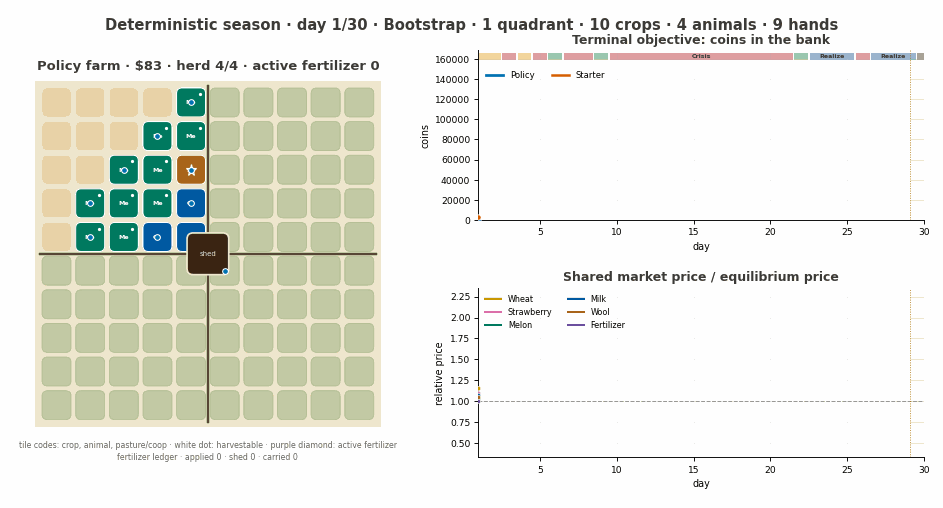

In [7]:
import base64
from io import BytesIO
from matplotlib.patches import FancyBboxPatch
from PIL import Image as PILImage
from IPython.display import HTML, display

TRAJECTORY_SEED = 217
TRAJECTORY_FRAME_DURATION_MS = 1500
TRAJECTORY_DPI = 82
TRAJECTORY_PRODUCTS = (
    "WHEAT",
    "STRAWBERRY",
    "MELON",
    "MILK",
    "WOOL",
    "FERTILIZER",
)

trajectory_env = make(
    "kaggriculture",
    configuration={
        "seed": TRAJECTORY_SEED,
        "episodeSteps": 720,
    },
    debug=True,
)
trajectory_env.run([candidate_agent, "starter"])
trajectory_steps = trajectory_env.steps

assert len(trajectory_steps) == 720
assert all(
    str(player.status) == "DONE"
    for player in trajectory_steps[-1]
)

turns_per_day = int(trajectory_env.configuration.turnsPerDay)
frame_indices = [
    min(turns_per_day * day - 1, len(trajectory_steps) - 1)
    for day in range(1, 31)
]
assert len(frame_indices) == len(set(frame_indices)) == 30

CROP_COLORS = {
    "WHEAT": "#C99700",
    "CARROT": "#B84A00",
    "TOMATO": "#9E2B72",
    "STRAWBERRY": "#DB6FA9",
    "MELON": "#00795F",
}
PRODUCT_COLORS = {
    **CROP_COLORS,
    "EGG": "#56A8D8",
    "MILK": "#0059A1",
    "WOOL": "#A8641A",
    "FERTILIZER": "#6B4F9E",
}
CROP_LABELS = {
    "WHEAT": "Wh",
    "CARROT": "Ca",
    "TOMATO": "To",
    "STRAWBERRY": "St",
    "MELON": "Me",
}
ANIMAL_LABELS = {
    "CHICKEN": "Ch",
    "COW": "Co",
    "SHEEP": "Sh",
    "GOOSE": "Go",
}
ANIMAL_PRODUCTS = {
    "CHICKEN": "EGG",
    "COW": "MILK",
    "SHEEP": "WOOL",
    "GOOSE": "EGG",
}
MARKET_BASE = {
    "WHEAT": 25,
    "STRAWBERRY": 120,
    "MELON": 250,
    "MILK": 160,
    "WOOL": 200,
    "FERTILIZER": 100,
}
SOIL = "#EFE7CE"
TILLED = "#E8D2A6"
WILD = "#C2CAA4"
WOOD = "#8B6F44"
WOOD_DARK = "#3A2412"
INK = "#3C3B37"
POLICY_COLOR = "#0072B2"
STARTER_COLOR = "#D55E00"

def draw_policy_farm(axis, farm, day=None, show_workers=True):
    board_size = len(farm["tiles"])

    def rounded_tile(
        x,
        y,
        facecolor,
        edgecolor="white",
        linewidth=0.8,
        alpha=1.0,
    ):
        axis.add_patch(
            FancyBboxPatch(
                (x + 0.07, board_size - 1 - y + 0.07),
                0.86,
                0.86,
                boxstyle="round,pad=0,rounding_size=0.16",
                facecolor=facecolor,
                edgecolor=edgecolor,
                linewidth=linewidth,
                alpha=alpha,
            )
        )

    axis.add_patch(
        plt.Rectangle(
            (-0.15, -0.15),
            board_size + 0.30,
            board_size + 0.30,
            facecolor=SOIL,
            edgecolor="none",
            zorder=0,
        )
    )
    for y, row in enumerate(farm["tiles"]):
        for x, tile in enumerate(row):
            if tile == "LOCKED":
                rounded_tile(x, y, WILD, "#B3BD94")
                continue

            rounded_tile(x, y, TILLED, SOIL)
            if not isinstance(tile, dict):
                continue

            kind = tile.get("kind")
            center = (x + 0.50, board_size - 1 - y + 0.50)
            if kind == "PLANT":
                crop = tile["crop"]
                harvestable = tile.get("yield_units", 0) > 0
                rounded_tile(
                    x,
                    y,
                    CROP_COLORS[crop],
                    alpha=1.0 if harvestable else 0.45,
                )
                axis.text(
                    *center,
                    CROP_LABELS[crop],
                    ha="center",
                    va="center",
                    fontsize=5.5,
                    color="white" if harvestable else INK,
                    weight="bold",
                    zorder=6,
                )
                if harvestable:
                    axis.plot(
                        center[0] + 0.25,
                        center[1] + 0.25,
                        "o",
                        markersize=2.8,
                        markerfacecolor="white",
                        markeredgecolor="none",
                        zorder=7,
                    )
                fertilized_until = tile.get(
                    "fertilized_until_day", -1
                )
                if (
                    day is not None
                    and fertilized_until is not None
                    and int(fertilized_until) >= int(day)
                ):
                    axis.plot(
                        center[0] - 0.25,
                        center[1] + 0.25,
                        marker="D",
                        markersize=4.8,
                        markerfacecolor=PRODUCT_COLORS["FERTILIZER"],
                        markeredgecolor="white",
                        markeredgewidth=0.7,
                        zorder=7,
                    )
            elif kind == "WEED":
                rounded_tile(x, y, "#6E7351", alpha=0.60)
                axis.text(
                    *center,
                    "×",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color="white",
                    weight="bold",
                    zorder=6,
                )
            elif "animal" in tile:
                animal = tile["animal"]
                rounded_tile(
                    x,
                    y,
                    PRODUCT_COLORS[ANIMAL_PRODUCTS[animal]],
                )
                axis.text(
                    *center,
                    ANIMAL_LABELS[animal],
                    ha="center",
                    va="center",
                    fontsize=5.5,
                    color="white",
                    weight="bold",
                    zorder=6,
                )
            elif kind in ("COOP", "PASTURE"):
                rounded_tile(x, y, WOOD, alpha=0.55)
                axis.text(
                    *center,
                    "Cp" if kind == "COOP" else "Pa",
                    ha="center",
                    va="center",
                    fontsize=5.5,
                    color="white",
                    weight="bold",
                    zorder=6,
                )

    half = board_size / 2
    axis.plot(
        [half, half],
        [0, board_size],
        color=WOOD_DARK,
        linewidth=2.1,
        alpha=0.82,
        zorder=4,
    )
    axis.plot(
        [0, board_size],
        [half, half],
        color=WOOD_DARK,
        linewidth=2.1,
        alpha=0.82,
        zorder=4,
    )
    axis.add_patch(
        FancyBboxPatch(
            (half - 0.62, half - 0.62),
            1.24,
            1.24,
            boxstyle="round,pad=0,rounding_size=0.18",
            facecolor=WOOD_DARK,
            edgecolor=SOIL,
            linewidth=1.5,
            zorder=7,
        )
    )
    axis.text(
        half,
        half,
        "shed",
        ha="center",
        va="center",
        fontsize=6.2,
        color=SOIL,
        zorder=8,
    )

    if show_workers:
        farmer_x, farmer_y = farm["farmer"]
        axis.plot(
            farmer_x + 0.50,
            board_size - 1 - farmer_y + 0.50,
            marker="*",
            markersize=10,
            markerfacecolor=POLICY_COLOR,
            markeredgecolor="white",
            markeredgewidth=1.0,
            zorder=9,
        )
        for hand_x, hand_y in farm.get("hands", []):
            axis.plot(
                hand_x + 0.50,
                board_size - 1 - hand_y + 0.50,
                "o",
                markersize=5,
                markerfacecolor=POLICY_COLOR,
                markeredgecolor="white",
                markeredgewidth=0.9,
                zorder=9,
            )

    axis.set_xlim(-0.20, board_size + 0.20)
    axis.set_ylim(-0.20, board_size + 0.20)
    axis.set_aspect("equal")
    axis.axis("off")
    axis.grid(False)

daily_observations = [
    trajectory_steps[index][0]["observation"]
    for index in frame_indices
]
day_axis = list(range(1, len(daily_observations) + 1))

fertilizer_events = []
for source_index in range(len(trajectory_steps) - 1):
    source_observation = trajectory_steps[source_index][0][
        "observation"
    ]
    recorded_action = (
        trajectory_steps[source_index + 1][0].get("action") or {}
    )
    unit_actions = [
        recorded_action.get("farmer", ["PASS"]),
        *(recorded_action.get("hands", []) or []),
    ]
    application_count = sum(
        bool(action) and action[0] == "FERTILIZE"
        for action in unit_actions
    )
    if application_count:
        fertilizer_events.append(
            {
                "source_index": source_index,
                "display_day": int(
                    source_observation.get("day", 0) or 0
                )
                + 1,
                "count": application_count,
            }
        )

policy_state_history = []
for observation, frame_index in zip(
    daily_observations,
    frame_indices,
):
    farm = observation["farms"][0]
    private = observation.get("private", {}) or {}
    roles = module._role_plan(observation, farm)
    summary = module._survey(
        farm,
        private,
        roles,
        int(observation.get("day", 0) or 0),
    )
    policy_state_history.append(
        {
            "phase": module._policy_phase(
                observation,
                farm,
                private,
                summary,
            ),
            "animals": summary["animals"],
            "herd_target": sum(
                role[0] == "ANIMAL" for role in roles.values()
            ),
            "fertilized_tiles": sum(
                isinstance(tile, dict)
                and tile.get("kind") == "PLANT"
                and int(
                    tile.get("fertilized_until_day", -1) or -1
                )
                >= int(observation.get("day", 0) or 0)
                for row in farm["tiles"]
                for tile in row
            ),
            "fertilizer_shed": int(
                (private.get("shed", {}) or {}).get(
                    "FERTILIZER", 0
                )
                or 0
            ),
            "fertilizer_carried": sum(
                int(inventory.get("FERTILIZER", 0) or 0)
                for inventory in (
                    private.get("inventories", []) or []
                )
            ),
            "fertilizer_applications": sum(
                event["count"]
                for event in fertilizer_events
                if event["source_index"] < frame_index
            ),
        }
    )
assert policy_state_history[-1]["fertilizer_applications"] == sum(
    event["count"] for event in fertilizer_events
)

phase_segments = []
for display_day, state in zip(day_axis, policy_state_history):
    phase = state["phase"]
    if phase_segments and phase_segments[-1][0] == phase:
        phase_segments[-1][2] = display_day
    else:
        phase_segments.append([phase, display_day, display_day])
PHASE_COLORS = {
    "BOOTSTRAP": "#E8B44B",
    "COMPOUND": "#4F9D69",
    "REALIZE": "#4C78A8",
    "CRISIS": "#C44E52",
    "LIQUIDATE": "#8C6D31",
}
LIQUIDATION_STEP = 719 - module.LIQUIDATION_TURNS
LIQUIDATION_DAY_X = (LIQUIDATION_STEP + 1) / turns_per_day
bank_history = {
    "Policy": [
        float(observation["farms"][0]["money"])
        for observation in daily_observations
    ],
    "Starter": [
        float(observation["farms"][1]["money"])
        for observation in daily_observations
    ],
}
price_history = {
    item: [
        float(observation["market"]["prices"][item])
        / MARKET_BASE[item]
        for observation in daily_observations
    ]
    for item in TRAJECTORY_PRODUCTS
}

bank_ceiling = 1.08 * max(
    max(values) for values in bank_history.values()
)
all_price_ratios = [
    value
    for values in price_history.values()
    for value in values
]
ratio_span = max(all_price_ratios) - min(all_price_ratios)
ratio_pad = max(0.05, 0.08 * ratio_span)
ratio_limits = (
    min(all_price_ratios) - ratio_pad,
    max(all_price_ratios) + ratio_pad,
)

figure = plt.figure(
    figsize=(11.5, 6.2),
    dpi=TRAJECTORY_DPI,
    facecolor="white",
)
grid = figure.add_gridspec(
    2,
    2,
    width_ratios=(1.02, 1.30),
    height_ratios=(1, 1),
)
farm_axis = figure.add_subplot(grid[:, 0])
bank_axis = figure.add_subplot(grid[0, 1])
market_axis = figure.add_subplot(grid[1, 1])
figure.subplots_adjust(
    left=0.035,
    right=0.98,
    bottom=0.10,
    top=0.90,
    wspace=0.24,
    hspace=0.40,
)

def style_series_axis(axis):
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(alpha=0.20, linewidth=0.7)
    axis.tick_params(labelsize=8)

def render_trajectory_frame(frame_number):
    farm_axis.clear()
    bank_axis.clear()
    market_axis.clear()

    observation = daily_observations[frame_number]
    farm = observation["farms"][0]
    policy_state = policy_state_history[frame_number]
    draw_policy_farm(
        farm_axis,
        farm,
        day=int(observation.get("day", 0) or 0),
    )

    tiles = [tile for row in farm["tiles"] for tile in row]
    plant_count = sum(
        isinstance(tile, dict) and tile.get("kind") == "PLANT"
        for tile in tiles
    )
    animal_count = sum(
        isinstance(tile, dict) and "animal" in tile
        for tile in tiles
    )
    unlocked = len(farm.get("unlocked_quadrants", []))
    farm_axis.set_title(
        (
            f"Policy farm · ${farm['money']:,.0f} · "
            f"herd {animal_count}/{policy_state['herd_target']} · "
            f"active fertilizer {policy_state['fertilized_tiles']}"
        ),
        fontsize=11.5,
        color=INK,
        weight="bold",
        pad=8,
    )
    farm_axis.text(
        0.5,
        -0.035,
        (
            "tile codes: crop, animal, pasture/coop · white dot: "
            "harvestable · purple diamond: active fertilizer\n"
            f"fertilizer ledger · applied "
            f"{policy_state['fertilizer_applications']} · "
            f"shed {policy_state['fertilizer_shed']} · "
            f"carried {policy_state['fertilizer_carried']}"
        ),
        transform=farm_axis.transAxes,
        ha="center",
        va="top",
        fontsize=6.9,
        color="#6A6861",
        linespacing=1.35,
    )

    visible_days = day_axis[: frame_number + 1]
    bank_axis.plot(
        visible_days,
        bank_history["Policy"][: frame_number + 1],
        color=POLICY_COLOR,
        linewidth=2.4,
        label="Policy",
    )
    bank_axis.plot(
        visible_days,
        bank_history["Starter"][: frame_number + 1],
        color=STARTER_COLOR,
        linewidth=2.2,
        label="Starter",
    )
    bank_axis.scatter(
        visible_days[-1],
        bank_history["Policy"][frame_number],
        s=22,
        color=POLICY_COLOR,
        edgecolor="white",
        linewidth=0.7,
        zorder=5,
    )
    bank_axis.scatter(
        visible_days[-1],
        bank_history["Starter"][frame_number],
        s=22,
        color=STARTER_COLOR,
        edgecolor="white",
        linewidth=0.7,
        zorder=5,
    )
    visible_fertilizer_events = [
        event
        for event in fertilizer_events
        if event["source_index"]
        < frame_indices[frame_number]
    ]
    fertilizer_by_day = {}
    for event in visible_fertilizer_events:
        display_day = event["display_day"]
        fertilizer_by_day[display_day] = (
            fertilizer_by_day.get(display_day, 0)
            + event["count"]
        )
    if fertilizer_by_day:
        event_days = sorted(fertilizer_by_day)
        bank_axis.scatter(
            event_days,
            [0.035 * bank_ceiling] * len(event_days),
            s=[
                16 + 5 * fertilizer_by_day[display_day]
                for display_day in event_days
            ],
            marker="D",
            color=PRODUCT_COLORS["FERTILIZER"],
            edgecolor="white",
            linewidth=0.6,
            alpha=0.85,
            label="Fertilize",
            zorder=6,
        )
    for phase, first_day, last_day in phase_segments:
        bank_axis.axvspan(
            first_day - 0.45,
            last_day + 0.45,
            ymin=0.945,
            ymax=0.985,
            color=PHASE_COLORS[phase],
            alpha=0.55,
            linewidth=0,
            zorder=1,
        )
        if last_day - first_day >= 2:
            bank_axis.text(
                (first_day + last_day) / 2,
                0.965,
                phase.title(),
                transform=bank_axis.get_xaxis_transform(),
                ha="center",
                va="center",
                fontsize=5.5,
                color="#383733",
                weight="bold",
                zorder=7,
            )
    bank_axis.axvspan(
        LIQUIDATION_DAY_X,
        30,
        color="#E69F00",
        alpha=0.10,
        linewidth=0,
        zorder=0,
    )
    bank_axis.axvline(
        LIQUIDATION_DAY_X,
        color="#A66C00",
        linewidth=0.8,
        linestyle=":",
        alpha=0.75,
    )
    bank_axis.set_xlim(1, 30)
    bank_axis.set_ylim(0, bank_ceiling)
    bank_axis.set_title(
        "Terminal objective: coins in the bank",
        fontsize=11,
        color=INK,
        weight="bold",
    )
    bank_axis.set_xlabel("day", fontsize=8.5)
    bank_axis.set_ylabel("coins", fontsize=8.5)
    bank_axis.legend(
        loc="upper left",
        bbox_to_anchor=(0.0, 0.925),
        frameon=False,
        fontsize=7.5,
        ncol=3,
    )
    style_series_axis(bank_axis)

    for item in TRAJECTORY_PRODUCTS:
        market_axis.plot(
            visible_days,
            price_history[item][: frame_number + 1],
            color=PRODUCT_COLORS[item],
            linewidth=1.8,
            label=item.title(),
        )
        market_axis.scatter(
            visible_days[-1],
            price_history[item][frame_number],
            s=14,
            color=PRODUCT_COLORS[item],
            edgecolor="white",
            linewidth=0.5,
            zorder=5,
        )
    market_axis.axhline(
        1.0,
        color="#7A7770",
        linewidth=0.9,
        linestyle="--",
        alpha=0.75,
    )
    market_axis.axvspan(
        LIQUIDATION_DAY_X,
        30,
        color="#E69F00",
        alpha=0.10,
        linewidth=0,
        zorder=0,
    )
    market_axis.axvline(
        LIQUIDATION_DAY_X,
        color="#A66C00",
        linewidth=0.8,
        linestyle=":",
        alpha=0.75,
    )
    market_axis.set_xlim(1, 30)
    market_axis.set_ylim(*ratio_limits)
    market_axis.set_title(
        "Shared market price / equilibrium price",
        fontsize=11,
        color=INK,
        weight="bold",
    )
    market_axis.set_xlabel("day", fontsize=8.5)
    market_axis.set_ylabel("relative price", fontsize=8.5)
    market_axis.legend(
        loc="upper left",
        frameon=False,
        fontsize=7,
        ncol=2,
    )
    style_series_axis(market_axis)

    figure.suptitle(
        (
            f"Deterministic season · day {frame_number + 1}/30 · "
            f"{policy_state['phase'].title()} · "
            f"{unlocked} "
            f"{'quadrant' if unlocked == 1 else 'quadrants'} · "
            f"{plant_count} crops · "
            f"{animal_count} animals · {len(farm.get('hands', []))} hands"
        ),
        fontsize=13,
        color=INK,
        weight="bold",
        y=0.965,
    )

rendered_frames = []
for frame_number in range(len(frame_indices)):
    render_trajectory_frame(frame_number)
    frame_buffer = BytesIO()
    figure.savefig(
        frame_buffer,
        format="png",
        dpi=TRAJECTORY_DPI,
        facecolor="white",
    )
    frame_buffer.seek(0)
    with PILImage.open(frame_buffer) as frame_image:
        rendered_frames.append(frame_image.convert("RGBA"))

animation_buffer = BytesIO()
rendered_frames[0].save(
    animation_buffer,
    format="GIF",
    save_all=True,
    append_images=rendered_frames[1:],
    duration=TRAJECTORY_FRAME_DURATION_MS,
    loop=0,
    disposal=2,
    optimize=True,
)
plt.close(figure)
for frame_image in rendered_frames:
    frame_image.close()
gif_bytes = animation_buffer.getvalue()

with PILImage.open(BytesIO(gif_bytes)) as rendered_gif:
    gif_dimensions = rendered_gif.size
    gif_frames = rendered_gif.n_frames
    gif_loop = rendered_gif.info.get("loop")

assert gif_frames == 30
assert gif_loop == 0
assert gif_bytes[:6] in (b"GIF87a", b"GIF89a")

animation_alt = (
    "Thirty-day deterministic policy farm, bank, and "
    "shared-market trajectory."
)
gif_base64 = base64.b64encode(gif_bytes).decode("ascii")
animation_html = (
    '<img src="data:image/gif;base64,'
    + gif_base64
    + '" alt="'
    + animation_alt
    + f'" width="{gif_dimensions[0]}" height="{gif_dimensions[1]}" '
    + 'style="display:block;width:100%;max-width:'
    + f'{gif_dimensions[0]}px;height:auto;margin:0 auto;" />'
)
display(HTML(animation_html))


## 11. Within-day routing

Displayed Day 21 is the first day with the expanded labor ceiling.
For hour $h\in\{0,\ldots,23\}$, the routing state is

$$
\mathcal R_h=
\left(X_h,A_h,J_h,Z_h,M_h\right),
$$

where $X_h$ contains unit positions, $A_h$ issued field actions,
$J_h$ pending jobs, $Z_h$ carried and shed inventories, and $M_h$
simultaneous market orders. Feasibility follows

$$
A_h(i)\in\mathcal A_i(X_h,J_h,Z_h),
\qquad
\sum_j\mathbf 1[A_h(i)=j]\le1.
$$

Frame-to-frame continuity checks that collection changes carried
stock before a later application and that unavailable operation
families remain absent rather than inferred. One second per hourly
frame gives a $24$-second cycle.


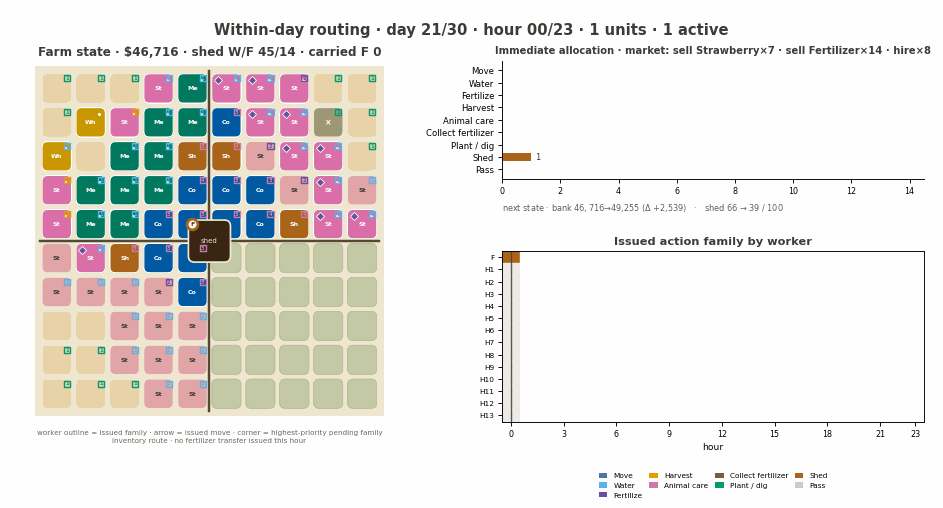

In [8]:
import base64
import copy
from collections import Counter, defaultdict
from io import BytesIO

import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from PIL import Image as PILImage
from IPython.display import HTML, display

ROUTING_DAY = 21
ROUTING_FRAME_DURATION_MS = 1000
ROUTING_DPI = 82
ROUTING_REQUIRED_OPERATIONS = {
    "PICKUP",
    "DROP",
    "WATER",
    "FERTILIZE",
    "HARVEST",
    "FEED",
    "CARE",
    "COLLECT_FERTILIZER",
}

routing_indices = [
    index
    for index in range(len(trajectory_steps) - 1)
    if int(
        trajectory_steps[index][0]["observation"].get("day", -1)
    )
    == ROUTING_DAY - 1
]
routing_observations = [
    trajectory_steps[index][0]["observation"]
    for index in routing_indices
]
routing_actions = [
    trajectory_steps[index + 1][0].get("action") or {}
    for index in routing_indices
]
routing_post_observations = [
    trajectory_steps[index + 1][0]["observation"]
    for index in routing_indices
]

assert len(routing_indices) == 24
assert [
    int(observation.get("hour", -1))
    for observation in routing_observations
] == list(range(24))
assert all(
    candidate_agent(
        copy.deepcopy(observation),
        trajectory_env.configuration,
    )
    == action
    for observation, action in zip(
        routing_observations,
        routing_actions,
    )
)

def issued_unit_actions(action):
    return [
        action.get("farmer", ["PASS"]),
        *(action.get("hands", []) or []),
    ]

def unit_positions(observation):
    farm = observation["farms"][0]
    return [
        tuple(farm["farmer"]),
        *(tuple(position) for position in farm.get("hands", [])),
    ]

routing_positions = [
    unit_positions(observation)
    for observation in routing_observations
]
routing_unit_actions = [
    issued_unit_actions(action) for action in routing_actions
]
assert all(
    len(positions) == len(actions)
    for positions, actions in zip(
        routing_positions,
        routing_unit_actions,
    )
)

routing_operations = {
    action[0]
    for actions in routing_unit_actions
    for action in actions
    if action
}
routing_max_units = max(map(len, routing_positions))
routing_fertilizer_events = [
    (hour, unit_index, action[0])
    for hour, actions in enumerate(routing_unit_actions)
    for unit_index, action in enumerate(actions)
    if action
    and action[0] in {"COLLECT_FERTILIZER", "FERTILIZE"}
]
ROUTING_FERTILIZER_WORKER = next(
    (
        unit_index
        for _, unit_index, operation in routing_fertilizer_events
        if operation == "COLLECT_FERTILIZER"
    ),
    next(
        (
            unit_index
            for _, unit_index, _ in routing_fertilizer_events
        ),
        -1,
    ),
)
routing_focus_hours = [
    hour
    for hour, unit_index, _ in routing_fertilizer_events
    if unit_index == ROUTING_FERTILIZER_WORKER
]
ROUTING_FERTILIZER_START = (
    min(routing_focus_hours) if routing_focus_hours else 24
)
ROUTING_FERTILIZER_END = (
    max(routing_focus_hours) if routing_focus_hours else -1
)

ROUTING_MOVE_DELTAS = {
    "NORTH": (0, -1),
    "WEST": (-1, 0),
    "SOUTH": (0, 1),
    "EAST": (1, 0),
}
ROUTING_CATEGORIES = (
    "Move",
    "Water",
    "Fertilize",
    "Harvest",
    "Animal care",
    "Collect fertilizer",
    "Plant / dig",
    "Shed",
    "Pass",
    "Absent",
    "Future",
)
ROUTING_COLORS = {
    "Move": "#4C78A8",
    "Water": "#56B4E9",
    "Fertilize": "#6B4F9E",
    "Harvest": "#E69F00",
    "Animal care": "#CC79A7",
    "Collect fertilizer": "#7A5C3E",
    "Plant / dig": "#009E73",
    "Shed": "#B5651D",
    "Pass": "#C9C7C1",
    "Absent": "#ECEAE5",
    "Future": "#FFFFFF",
}
ROUTING_CATEGORY_CODE = {
    category: index
    for index, category in enumerate(ROUTING_CATEGORIES)
}

def routing_category(action):
    operation = action[0] if action else "PASS"
    if operation in ROUTING_MOVE_DELTAS:
        return "Move"
    if operation == "WATER":
        return "Water"
    if operation == "FERTILIZE":
        return "Fertilize"
    if operation == "HARVEST":
        return "Harvest"
    if operation in {"FEED", "CARE"}:
        return "Animal care"
    if operation == "COLLECT_FERTILIZER":
        return "Collect fertilizer"
    if operation in {
        "PLANT",
        "DIG",
        "BUILD_COOP",
        "BUILD_PASTURE",
    }:
        return "Plant / dig"
    if operation in {"PICKUP", "DROP", "PLACE"}:
        return "Shed"
    if operation == "PASS":
        return "Pass"
    raise AssertionError(f"unmapped routing operation: {operation}")

routing_schedule = np.full(
    (routing_max_units, 24),
    ROUTING_CATEGORY_CODE["Absent"],
    dtype=int,
)
for hour, actions in enumerate(routing_unit_actions):
    for unit_index, action in enumerate(actions):
        routing_schedule[unit_index, hour] = (
            ROUTING_CATEGORY_CODE[routing_category(action)]
        )

def pending_target_summary(observation):
    farm = observation["farms"][0]
    private = observation.get("private", {}) or {}
    roles = module._role_plan(observation, farm)
    actions_left = max(
        0,
        719 - int(observation.get("step", 0) or 0),
    )
    jobs = module._field_jobs(
        observation,
        farm,
        private,
        roles,
        actions_left <= module.LIQUIDATION_TURNS,
    )
    grouped = defaultdict(list)
    for job in jobs:
        grouped[tuple(job["target"])].append(job)
    summary = {}
    for target, target_jobs in grouped.items():
        dominant = min(
            target_jobs,
            key=lambda job: (
                int(job["priority"]),
                -float(job["value"]),
                str(job["action"][0]),
            ),
        )
        summary[target] = {
            "count": len(target_jobs),
            "category": routing_category(dominant["action"]),
        }
    return summary

routing_pending_targets = [
    pending_target_summary(observation)
    for observation in routing_observations
]

routing_figure = plt.figure(
    figsize=(11.5, 6.2),
    dpi=ROUTING_DPI,
    facecolor="white",
)
routing_grid = routing_figure.add_gridspec(
    2,
    2,
    width_ratios=(1.02, 1.22),
    height_ratios=(0.82, 1.18),
)
routing_farm_axis = routing_figure.add_subplot(
    routing_grid[:, 0]
)
routing_allocation_axis = routing_figure.add_subplot(
    routing_grid[0, 1]
)
routing_schedule_axis = routing_figure.add_subplot(
    routing_grid[1, 1]
)
routing_figure.subplots_adjust(
    left=0.035,
    right=0.98,
    bottom=0.17,
    top=0.88,
    wspace=0.30,
    hspace=0.50,
)

routing_cmap = ListedColormap(
    [ROUTING_COLORS[category] for category in ROUTING_CATEGORIES]
)
routing_worker_labels = [
    "F",
    *(f"H{index}" for index in range(1, routing_max_units)),
]
routing_bar_categories = ROUTING_CATEGORIES[:9]

def routing_plot_position(position):
    x, y = position
    board_size = len(routing_observations[0]["farms"][0]["tiles"])
    return x + 0.50, board_size - 1 - y + 0.50

def routing_offsets(positions):
    groups = defaultdict(list)
    for unit_index, position in enumerate(positions):
        groups[position].append(unit_index)
    offsets = {}
    for members in groups.values():
        count = len(members)
        for order, unit_index in enumerate(members):
            if count == 1:
                offsets[unit_index] = (0.0, 0.0)
            else:
                angle = 2.0 * np.pi * order / count
                offsets[unit_index] = (
                    0.17 * np.cos(angle),
                    0.17 * np.sin(angle),
                )
    return offsets

def render_routing_frame(frame_number):
    routing_farm_axis.clear()
    routing_allocation_axis.clear()
    routing_schedule_axis.clear()

    observation = routing_observations[frame_number]
    farm = observation["farms"][0]
    private = observation.get("private", {}) or {}
    positions = routing_positions[frame_number]
    actions = routing_unit_actions[frame_number]
    hour = int(observation["hour"])

    draw_policy_farm(
        routing_farm_axis,
        farm,
        day=int(observation.get("day", 0) or 0),
        show_workers=False,
    )

    for unit_index in range(routing_max_units):
        trail = []
        for history_index in range(
            max(0, frame_number - 4),
            frame_number + 1,
        ):
            historical_positions = routing_positions[history_index]
            if unit_index < len(historical_positions):
                trail.append(
                    routing_plot_position(
                        historical_positions[unit_index]
                    )
                )
        if len(trail) >= 2:
            fertilizer_route = (
                unit_index == ROUTING_FERTILIZER_WORKER
                and ROUTING_FERTILIZER_START
                <= frame_number
                <= ROUTING_FERTILIZER_END
            )
            routing_farm_axis.plot(
                [point[0] for point in trail],
                [point[1] for point in trail],
                color=(
                    ROUTING_COLORS["Fertilize"]
                    if fertilizer_route
                    else POLICY_COLOR
                ),
                linewidth=2.1 if fertilizer_route else 1.0,
                alpha=0.72 if fertilizer_route else 0.22,
                zorder=8,
            )

    for target, pending in routing_pending_targets[
        frame_number
    ].items():
        target_x, target_y = routing_plot_position(target)
        pending_color = ROUTING_COLORS[pending["category"]]
        routing_farm_axis.scatter(
            target_x + 0.30,
            target_y + 0.30,
            marker="s",
            s=28,
            facecolors="none",
            edgecolors=pending_color,
            linewidths=1.25,
            zorder=10,
        )
        routing_farm_axis.text(
            target_x + 0.30,
            target_y + 0.30,
            str(pending["count"]),
            ha="center",
            va="center",
            fontsize=4.6,
            color=pending_color,
            weight="bold",
            zorder=11,
        )

    offsets = routing_offsets(positions)
    for unit_index, (position, action) in enumerate(
        zip(positions, actions)
    ):
        operation = action[0] if action else "PASS"
        category = routing_category(action)
        color = ROUTING_COLORS[category]
        x, y = routing_plot_position(position)
        offset_x, offset_y = offsets[unit_index]
        marker_x = x + offset_x
        marker_y = y + offset_y

        if operation in ROUTING_MOVE_DELTAS:
            delta_x, delta_y = ROUTING_MOVE_DELTAS[operation]
            destination = (
                position[0] + delta_x,
                position[1] + delta_y,
            )
            destination_x, destination_y = routing_plot_position(
                destination
            )
            routing_farm_axis.annotate(
                "",
                xy=(destination_x + offset_x, destination_y + offset_y),
                xytext=(marker_x, marker_y),
                arrowprops={
                    "arrowstyle": "-|>",
                    "color": color,
                    "linewidth": 1.5,
                    "alpha": 0.85,
                    "shrinkA": 4,
                    "shrinkB": 4,
                },
                zorder=11,
            )

        routing_farm_axis.scatter(
            marker_x,
            marker_y,
            s=70 if unit_index else 88,
            facecolor="white",
            edgecolor=color,
            linewidth=1.8 if unit_index else 2.4,
            zorder=12,
        )
        routing_farm_axis.text(
            marker_x,
            marker_y,
            "F" if unit_index == 0 else str(unit_index),
            ha="center",
            va="center",
            fontsize=5.5,
            color=INK,
            weight="bold",
            zorder=13,
        )

    carried = Counter()
    for inventory in private.get("inventories", []) or []:
        carried.update(
            {
                item: int(quantity or 0)
                for item, quantity in inventory.items()
                if int(quantity or 0) > 0
            }
        )
    shed = private.get("shed", {}) or {}
    carried_fertilizer = int(carried.get("FERTILIZER", 0) or 0)
    shed_fertilizer = int(shed.get("FERTILIZER", 0) or 0)
    if (
        0 <= ROUTING_FERTILIZER_WORKER < len(actions)
        and actions[ROUTING_FERTILIZER_WORKER]
    ):
        focus_operation = actions[ROUTING_FERTILIZER_WORKER][0]
        focus_label = routing_worker_labels[ROUTING_FERTILIZER_WORKER]
        fertilizer_focus = (
            f"{focus_label} fertilizer route · {focus_operation} · "
            f"carried F {carried_fertilizer}"
        )
    else:
        fertilizer_focus = (
            "inventory route · no fertilizer transfer issued this hour"
        )
    routing_farm_axis.set_title(
        (
            f"Farm state · ${farm['money']:,.0f} · "
            f"shed W/F {int(shed.get('WHEAT', 0) or 0)}/"
            f"{shed_fertilizer} · carried F {carried_fertilizer}"
        ),
        fontsize=10.5,
        color=INK,
        weight="bold",
        pad=8,
    )
    routing_farm_axis.text(
        0.5,
        -0.035,
        (
            "worker outline = issued family · arrow = issued move · "
            "corner = highest-priority pending family\n"
            + fertilizer_focus
    ),
        transform=routing_farm_axis.transAxes,
        ha="center",
        va="top",
        fontsize=6.4,
        color="#6A6861",
        linespacing=1.35,
    )

    current_categories = Counter(
        routing_category(action) for action in actions
    )
    bar_values = [
        current_categories[category]
        for category in routing_bar_categories
    ]
    assert sum(bar_values) == len(actions)
    bar_positions = np.arange(len(routing_bar_categories))
    routing_allocation_axis.barh(
        bar_positions,
        bar_values,
        color=[
            ROUTING_COLORS[category]
            for category in routing_bar_categories
        ],
        height=0.68,
    )
    routing_allocation_axis.set_yticks(bar_positions)
    routing_allocation_axis.set_yticklabels(
        routing_bar_categories,
        fontsize=7.5,
    )
    routing_allocation_axis.invert_yaxis()
    routing_allocation_axis.set_xlim(0, routing_max_units + 0.5)
    routing_allocation_axis.set_xticks(
        range(0, routing_max_units + 1, 2)
    )
    routing_allocation_axis.tick_params(axis="x", labelsize=7)
    routing_allocation_axis.grid(
        axis="x",
        alpha=0.20,
        linewidth=0.7,
    )
    routing_allocation_axis.spines["top"].set_visible(False)
    routing_allocation_axis.spines["right"].set_visible(False)
    for position, value in zip(bar_positions, bar_values):
        if value:
            routing_allocation_axis.text(
                value + 0.15,
                position,
                str(value),
                va="center",
                fontsize=7.5,
                color=INK,
            )

    market_groups = {}
    for order in routing_actions[frame_number].get("market", []):
        if not order:
            continue
        operation = order[0]
        item = order[1] if len(order) >= 2 else None
        quantity = (
            int(order[2])
            if len(order) >= 3
            else 1
        )
        key = (operation, item)
        market_groups[key] = market_groups.get(key, 0) + quantity

    market_labels = {
        "SELL": "sell",
        "BUY_PRODUCT": "buy",
        "BUY_SEED": "seed",
        "BUY_ANIMAL": "animal",
        "BUY_LAND": "land",
        "HIRE": "hire",
    }
    market_parts = []
    for (operation, item), quantity in market_groups.items():
        label = market_labels.get(operation, operation.lower())
        if item is not None:
            label += f" {item.title()}"
        market_parts.append(f"{label}×{quantity}")
    market_text = " · ".join(market_parts) if market_parts else "none"
    routing_allocation_axis.set_title(
        f"Immediate allocation · market: {market_text}",
        fontsize=8.8,
        color=INK,
        weight="bold",
        pad=6,
    )
    post_observation = routing_post_observations[frame_number]
    post_farm = post_observation["farms"][0]
    pre_shed_load = sum(
        int(quantity or 0) for quantity in shed.values()
    )
    post_shed = (
        post_observation.get("private", {}).get("shed", {}) or {}
    )
    post_shed_load = sum(
        int(quantity or 0) for quantity in post_shed.values()
    )
    money_delta = float(post_farm["money"]) - float(farm["money"])
    routing_allocation_axis.text(
        0.0,
        -0.19,
        (
            f"next state · bank ${farm['money']:,.0f} "
            f"→ ${post_farm['money']:,.0f} "
            f"(Δ {money_delta:+,.0f})   ·   "
            f"shed {pre_shed_load} → {post_shed_load} / 100"
        ),
        transform=routing_allocation_axis.transAxes,
        ha="left",
        va="top",
        fontsize=7.2,
        color="#5F5D57",
    )

    visible_schedule = routing_schedule.copy()
    visible_schedule[:, frame_number + 1 :] = (
        ROUTING_CATEGORY_CODE["Future"]
    )
    routing_schedule_axis.imshow(
        visible_schedule,
        cmap=routing_cmap,
        vmin=-0.5,
        vmax=len(ROUTING_CATEGORIES) - 0.5,
        interpolation="nearest",
        aspect="auto",
    )
    routing_schedule_axis.axvline(
        frame_number,
        color=INK,
        linewidth=1.2,
        alpha=0.85,
    )
    routing_schedule_axis.set_xticks(
        [0, 3, 6, 9, 12, 15, 18, 21, 23]
    )
    routing_schedule_axis.set_xticklabels(
        ["0", "3", "6", "9", "12", "15", "18", "21", "23"],
        fontsize=7,
    )
    routing_schedule_axis.set_yticks(
        range(routing_max_units)
    )
    routing_schedule_axis.set_yticklabels(
        routing_worker_labels,
        fontsize=6.5,
    )
    routing_schedule_axis.set_xticks(
        np.arange(-0.5, 24, 1),
        minor=True,
    )
    routing_schedule_axis.set_yticks(
        np.arange(-0.5, routing_max_units, 1),
        minor=True,
    )
    routing_schedule_axis.grid(
        which="minor",
        color="white",
        linewidth=0.35,
        alpha=0.75,
    )
    routing_schedule_axis.tick_params(which="minor", length=0)
    routing_schedule_axis.set_xlabel("hour", fontsize=8)
    routing_schedule_axis.set_title(
        "Issued action family by worker",
        fontsize=10,
        color=INK,
        weight="bold",
        pad=6,
    )
    routing_schedule_axis.legend(
        handles=[
            Patch(
                facecolor=ROUTING_COLORS[category],
                edgecolor="none",
                label=category,
            )
            for category in routing_bar_categories
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.26),
        ncol=4,
        frameon=False,
        fontsize=6.5,
        columnspacing=0.9,
        handlelength=1.2,
    )

    routing_figure.suptitle(
        (
            f"Within-day routing · day {ROUTING_DAY}/30 · "
            f"hour {hour:02d}/23 · {len(positions)} units · "
            f"{sum(action != ['PASS'] for action in actions)} active"
        ),
        fontsize=13,
        color=INK,
        weight="bold",
        y=0.955,
    )

routing_rendered_frames = []
for routing_frame_number in range(len(routing_indices)):
    render_routing_frame(routing_frame_number)
    routing_frame_buffer = BytesIO()
    routing_figure.savefig(
        routing_frame_buffer,
        format="png",
        dpi=ROUTING_DPI,
        facecolor="white",
    )
    routing_frame_buffer.seek(0)
    with PILImage.open(routing_frame_buffer) as routing_frame_image:
        routing_rendered_frames.append(
            routing_frame_image.convert("RGBA")
        )

routing_animation_buffer = BytesIO()
routing_rendered_frames[0].save(
    routing_animation_buffer,
    format="GIF",
    save_all=True,
    append_images=routing_rendered_frames[1:],
    duration=ROUTING_FRAME_DURATION_MS,
    loop=0,
    disposal=2,
    optimize=True,
)
plt.close(routing_figure)
for routing_frame_image in routing_rendered_frames:
    routing_frame_image.close()
routing_gif_bytes = routing_animation_buffer.getvalue()

with PILImage.open(BytesIO(routing_gif_bytes)) as routing_gif:
    routing_gif_dimensions = routing_gif.size
    routing_gif_frames = routing_gif.n_frames
    routing_gif_loop = routing_gif.info.get("loop")

assert routing_gif_frames == 24
assert routing_gif_loop == 0
assert routing_gif_bytes[:6] in (b"GIF87a", b"GIF89a")

routing_animation_alt = (
    "Twenty-four-hour worker routing, issued actions, pending "
    "targets, inventories, and simultaneous market orders on "
    "policy day twenty-one."
)
routing_gif_base64 = base64.b64encode(
    routing_gif_bytes
).decode("ascii")
routing_animation_html = (
    '<img src="data:image/gif;base64,'
    + routing_gif_base64
    + '" alt="'
    + routing_animation_alt
    + f'" width="{routing_gif_dimensions[0]}" '
    + f'height="{routing_gif_dimensions[1]}" '
    + 'style="display:block;width:100%;max-width:'
    + f'{routing_gif_dimensions[0]}px;height:auto;margin:0 auto;" />'
)
display(HTML(routing_animation_html))


In [9]:
import gzip
import hashlib
import io
import tarfile

payload = MAIN_PATH.read_bytes()
raw = io.BytesIO()
with gzip.GzipFile(
    fileobj=raw,
    mode="wb",
    filename="",
    mtime=0,
) as zipped:
    with tarfile.open(fileobj=zipped, mode="w") as archive:
        info = tarfile.TarInfo("main.py")
        info.size = len(payload)
        info.mode = 0o644
        info.mtime = 0
        info.uid = info.gid = 0
        info.uname = info.gname = ""
        archive.addfile(info, io.BytesIO(payload))

archive_path = WORK_DIR / "submission.tar.gz"
archive_path.write_bytes(raw.getvalue())
with tarfile.open(archive_path, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]
    assert archive.extractfile("main.py").read() == payload

print(
    {
        "archive": archive_path.name,
        "main_sha256": hashlib.sha256(payload).hexdigest(),
        "archive_sha256": hashlib.sha256(
            archive_path.read_bytes()
        ).hexdigest(),
    }
)

{'archive': 'submission.tar.gz', 'main_sha256': '88c2d49a64d3d6371de1e0b87bad9cf1a6afcbaf3b346934a8e9d2c8fdea5345', 'archive_sha256': '36f5b557a3e7a9df067523c3c81097a12577068e248439ed8c47fd9da680da75'}
